# Apart from returns, what other variables would make a good ML model?

1) Risk & distribution stats (from prices)

What: realized vol/semivol, downside deviation, skew/kurtosis, rolling drawdowns, rolling betas/correlations, idiosyncratic vol.

Where: compute from Ticker.history() (OHLCV). yfinance provides split/dividend-adjusted series; you compute the stats. 
ranaroussi.github.io

2) Factor exposures / factor returns

What: exposures to market, size, value, momentum, profitability, investment; later map to tracking error and factor constraints.

Where: use Kenneth French Data Library for daily/monthly factor returns (FF3/FF5/MOM), then run rolling regressions to get exposures. 
mba.tuck.dartmouth.edu

Alt: WRDS mirror if you have access. 
WRDS

3) Fundamentals & quality ratios

What: valuation (PE, PB, EV/EBITDA), margins, growth, leverage, accruals, payout—useful for quality/low-risk tilts and constraint sets.

Where (yf): Ticker.get_income_stmt()/balance_sheet/cashflow/financials + trailing/quarterly/ttm helpers. 
ranaroussi.github.io

Alt: Nasdaq Data Link (Sharadar SF1) for point-in-time standardized fundamentals. 
Nasdaq Data Link
Nasdaq Data Docs

4) Analyst expectations & revisions

What: EPS/revenue estimates, surprise history, revisions, price targets; strong signals for short-horizon BO objectives.

Where (yf): get_earnings_estimate, get_revenue_estimate, get_eps_revisions, analyst_price_targets, get_earnings_history. 
ranaroussi.github.io

5) Events calendar

What: earnings dates, ex-dividends, splits; use to manage blackout windows or add event-aware penalties in the acquisition function.

Where (yf): get_earnings_dates() and calendar. 
ranaroussi.github.io
+1

6) Dividends & buybacks

What: dividend yield/growth, payout stability; shares-outstanding trends to proxy buybacks.

Where (yf): dividends, shares/get_shares_full, actions. 
ranaroussi.github.io

7) Options-implied metrics

What: 30-day IV, IV term structure/skew, put-call ratios—useful as regime/state variables and for downside-aware objectives (e.g., CVaR).

Where (yf): option_chain() for quotes; compute IV/term structure yourself. 
ranaroussi.github.io

Benchmarks: VIX as a market-wide implied vol proxy (also downloadable as ^VIX). Methodology: Cboe docs. 
CBOE
+1

8) Liquidity & microstructure

What: ADV, turnover, Amihud illiquidity, bid-ask/effective spread; helpful for turnover and transaction-cost penalties.

Where (yf): volume/turnover from history() (compute features). 
ranaroussi.github.io

Top-of-book spread/quotes: Polygon.io NBBO quotes; IEX Cloud also exposes real-time/historical quotes. 
Polygon
Postman
PublicAPI

9) Short interest & stock-loan/borrow costs

What: short interest %, days-to-cover, borrow fee/utilization; useful for squeeze/overcrowding risk and borrow-cost-aware objectives.

Where (official): FINRA bi-monthly short interest files + metadata/API guidance. 
FINRA
+2
FINRA
+2

Aggregated: Nasdaq short interest pages/API via Data Link; Polygon short-interest endpoint (mirrors FINRA). 
Nasdaq
Nasdaq Data Docs
Polygon

Borrow fees: Interactive Brokers SLB Rates (GUI/API). 
IBKR Guides
Interactive Brokers

10) Insider & institutional flows

What: insider transactions/holdings; institutional holders; changes can be priors or constraints.

Where (yf): insider_transactions, insider_purchases, insider_roster_holders, institutional_holders. 
ranaroussi.github.io

Primary source: SEC EDGAR APIs (submissions & XBRL). 
SEC
+1

11) ESG & controversies

What: aggregate ESG scores or governance red flags to build “soft” constraints or additional objectives.

Where (yf): sustainability (when available). 
ranaroussi.github.io

Alt: commercial providers (MSCI/Sustainalytics/Refinitiv) if you need coverage/consistency.

12) Macro & rates (for risk-free, constraints, & regimes)

What: risk-free (1M–10Y UST), term spreads, credit spreads, inflation, unemployment, PMI; use as context features or regime switches.

Where: FRED API (and fredapi Python wrapper). 
FRED
GitHub

In [4]:
import pandas as pd
import yfinance as yf
import warnings
from marketmaven.utils import get_current_date

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3}'.format

# Date range
start = '2020-01-01'
end = get_current_date()
interval = "1d"  # Daily data

# Tickers of assets 
#assets = ['AVEM', 'XMMO', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VNQI', 'VNQ', 'SNPE', 'IEF', 'VBK'] # , 'AGEPX', 'SWSSX', 'SWVXX' mutual funds redundant 'AVES','VWOB',
TICKERS = ['AVEM', 'XMMO', 'ESGD', 'BYLD', 'ISCF', 'HYEM', 'VNQI', 'VNQ', 'SNPE', 'IEF', 'VBK']
TICKERS.sort()
raw_data = yf.download(TICKERS, start=start, end=end, auto_adjust=False, interval=interval)
data = raw_data.loc[:, ('Adj Close', slice(None))]
data.columns = TICKERS
data

[*********************100%***********************]  11 of 11 completed


,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,XMMO
Date,,,,,,,,,,,
2020-01-02,48.3,20.6,59.6,17.0,97.8,26.4,26.0,1.94e+02,74.4,50.2,58.7
2020-01-03,47.5,20.6,58.9,17.0,98.4,26.1,25.9,1.93e+02,74.9,50.0,58.7
2020-01-06,47.3,20.6,59.2,17.0,98.3,26.1,26.0,1.94e+02,75.0,49.8,58.8
2020-01-07,47.4,20.6,59.0,17.0,98.2,26.1,25.9,1.94e+02,74.2,49.7,58.6
2020-01-08,47.5,20.6,59.1,17.1,97.9,26.0,26.0,1.94e+02,74.4,49.4,58.7
...,...,...,...,...,...,...,...,...,...,...,...
2025-08-18,71.7,22.6,91.5,20.0,95.1,40.1,57.8,2.88e+02,88.9,47.0,1.3e+02
2025-08-19,70.9,22.6,91.4,20.0,95.4,40.1,57.6,2.85e+02,90.4,47.3,1.3e+02
2025-08-20,70.8,22.6,91.8,20.0,95.5,40.1,57.4,2.84e+02,90.7,47.5,1.3e+02


In [5]:
# Calculating returns

Y = data[TICKERS].pct_change().dropna()

display(Y.head())

,AVEM,BYLD,ESGD,HYEM,IEF,ISCF,SNPE,VBK,VNQ,VNQI,XMMO
Date,,,,,,,,,,,
2020-01-03,-0.0158,0.000972,-0.0118,-0.000418,0.00668,-0.0124,-0.00569,-0.00325,0.00622,-0.00454,0.000163
2020-01-06,-0.00418,-0.000816,0.00452,0.00209,-0.00108,0.00215,0.00322,0.00517,0.00119,-0.00507,0.0018
2020-01-07,9.15e-05,-0.000466,-0.00392,-0.000418,-0.00144,-0.00142,-0.00285,-0.0014,-0.0111,-0.00051,-0.00391
2020-01-08,0.00375,-0.00105,0.00233,0.00293,-0.00234,-0.00142,0.00357,0.0035,0.00307,-0.00629,0.00114
2020-01-09,0.00657,0.00214,0.0032,-0.000417,0.000721,0.00165,0.00854,0.00623,-0.000546,0.000171,0.00735


# Approach to building a model:

1. Create long dataset where each row is one asset-time observation.
2. Variables to include would be 
    - time
    - asset id
    -features for that assset at that date
    -features across assets at that data (macrorates, inflation, etc.).
    -maybe lags or rolling regressions
3. Target variable: y_excess_lead?? is the future excess total return for each asset over a fixed horizon h

# What exactly is the target?

	•	Use Adjusted Close from Yahoo Finance (yfinance) so dividends and splits are included in r_{i,t\to t+h}.
	•	The risk-free piece should be accrued over the same dates as the asset return.

### Create a long dataframe with y_excess_lead as the outptu variable

In [ ]:
# ==== CONFIG ====

START = start     # adjust as needed
END = get_current_date()                # None = up to today
HORIZON = "monthly"        # options: "weekly", "monthly", or "fixed"
FIXED_H_DAYS = 5          # only used if HORIZON == "fixed"

# ==== CODE ====
import numpy as np
import pandas as pd
import yfinance as yf

def fetch_prices(tickers, start, end=None):
    """
    Returns a tidy df with MultiIndex (date, ticker) and column 'Adj Close'.
    Adjusted Close includes dividends & splits => total-return compatible.
    """
    px = yf.download(
        tickers=tickers, start=start, end=end, interval="1d",
        group_by="ticker", auto_adjust=False, progress=False
    )
    # Normalize shape across yfinance versions
    if isinstance(px.columns, pd.MultiIndex):
        # Multi-index columns: level 0 = ticker, level 1 = field
        adj = []
        for tk in tickers:
            if (tk, 'Adj Close') in px.columns:
                s = px[(tk, 'Adj Close')].rename(tk)
                adj.append(s)
        adj = pd.concat(adj, axis=1)
    else:
        # Single-index columns: use 'Adj Close' directly (single ticker)
        adj = px[['Adj Close']].rename(columns={'Adj Close': tickers[0]})
    adj = adj.dropna(how="all")
    adj.index = pd.to_datetime(adj.index)
    return adj

def fetch_rf_daily(start, end=None):
    """
    Fetch ^IRX (13-week T-bill), robust to MultiIndex columns and auto_adjust True/False.
    Returns a daily series of *continuous* daily rate ≈ (annual_fraction / 252).
    """
    rf = yf.download("^IRX", start=start, end=end, interval="1d", progress=False, auto_adjust=False)

    if rf.empty:
        raise RuntimeError("Could not download ^IRX. Try expanding the date range.")

    # Handle both single-index and MultiIndex column shapes
    if isinstance(rf.columns, pd.MultiIndex):
        col = None
        candidates = [
            ("Adj Close", "^IRX"), ("Close", "^IRX"),
            ("^IRX", "Adj Close"), ("^IRX", "Close")
        ]
        for c in candidates:
            if c in rf.columns:
                col = rf.loc[:, c].astype(float)
                break
        if col is None:
            # Fallback: slice by level name, then pick the first column
            if "Adj Close" in rf.columns.get_level_values(0):
                col = rf.xs("Adj Close", level=0, axis=1).iloc[:, 0].astype(float)
            else:
                col = rf.xs("Close", level=0, axis=1).iloc[:, 0].astype(float)
    else:
        if "Adj Close" in rf.columns:
            col = rf["Adj Close"].astype(float)
        elif "Close" in rf.columns:
            col = rf["Close"].astype(float)
        else:
            raise KeyError(f"^IRX: Neither 'Adj Close' nor 'Close' in columns: {rf.columns.tolist()}")

    # Convert annualized percent -> fraction
    ann_frac = col / 100.0
    rf_daily_cont = ann_frac / 252.0
    rf_daily_cont.index = pd.to_datetime(rf_daily_cont.index)

    # Fill to business-day grid and forward-fill small gaps
    all_bd = pd.date_range(rf_daily_cont.index.min(), rf_daily_cont.index.max(), freq="B")
    rf_daily_cont = rf_daily_cont.reindex(all_bd).ffill()
    rf_daily_cont.name = "rf_daily_cont"
    return rf_daily_cont

def compute_excess_future_return_calendar(adj_close: pd.Series,
                                          rf_daily_cont: pd.Series,
                                          freq: str = "W-FRI"):
    """
    Calendar-aligned future excess return for one asset.
    y_excess = exp( log(P_{t1}) - log(P_t) - ∑_{(t,t1]} rf_daily_cont ) - 1
    Returns a Series indexed by the start-of-period date t.
    """
    # Resample to period-end closes
    px_period = adj_close.resample(freq).last().dropna()
    period_end = px_period.index
    px_fwd = px_period.shift(-1)

    # Price log-return for t -> t1
    log_r_price = (np.log(px_fwd) - np.log(px_period)).iloc[:-1]

    # Integrate RF over (t, t1] by summing continuous daily rates
    rf_log = []
    for t, t1 in zip(period_end[:-1], period_end[1:]):
        days = rf_daily_cont.loc[(rf_daily_cont.index > t) & (rf_daily_cont.index <= t1)]
        rf_log.append(days.sum() if not days.empty else 0.0)
    rf_log = pd.Series(rf_log, index=log_r_price.index)

    # Use numpy arrays to avoid dtype gotchas, then rebuild Series
    delta = (log_r_price.values - rf_log.values)
    y_excess_vals = np.exp(delta) - 1.0
    y_excess = pd.Series(y_excess_vals, index=log_r_price.index, name="y_excess_lead")
    return y_excess

def compute_excess_future_return_fixed(adj_close: pd.Series,
                                       rf_daily_cont: pd.Series,
                                       h_days: int = 5):
    """
    Fixed trading-day horizon (t -> t+h).
    y_excess = exp( log(P_{t+h}) - log(P_t) - sum_{k=0..h-1} rf_daily_cont[t+k] ) - 1
    """
    # Ensure we have RF on the same business-day index
    s = adj_close.dropna()
    idx = s.index
    rf_on_px = rf_daily_cont.reindex(idx).ffill()

    log_p = np.log(s)
    log_r_price = log_p.shift(-h_days * -1) - log_p  # log(P_{t+h}) - log(P_t); shift(-h) forward
    # Sum RF daily cont rates over next h days, aligned at t
    rf_log = rf_on_px.shift(-h_days + 1).rolling(h_days).sum()  # sum of future h days
    # Target
    y_excess = np.exp(log_r_price - rf_log) - 1.0
    y_excess = y_excess.iloc[:-h_days]  # drop last h because of lookahead
    y_excess.name = "y_excess_lead"
    return y_excess

def build_long_panel(tickers, start, end=None, horizon="weekly", fixed_h_days=5):
    prices = fetch_prices(tickers, start, end)
    rf_daily_cont = fetch_rf_daily(start, end)

    # Choose calendar frequency
    if horizon.lower() == "weekly":
        freq = "W-FRI"
        compute_fn = lambda s: compute_excess_future_return_calendar(s, rf_daily_cont, freq=freq)
    elif horizon.lower() == "monthly":
        freq = "BM" # Business Month-end
        compute_fn = lambda s: compute_excess_future_return_calendar(s, rf_daily_cont, freq=freq)
    elif horizon.lower() == "fixed":
        compute_fn = lambda s: compute_excess_future_return_fixed(s, rf_daily_cont, h_days=fixed_h_days)
    else:
        raise ValueError("horizon must be one of {'weekly','monthly','fixed'}")

    rows = []
    for tk in prices.columns:
        try:
            y_excess = compute_fn(prices[tk].dropna())
            df_tk = y_excess.to_frame()
            df_tk["asset_id"] = tk
            df_tk = df_tk.rename_axis("date").reset_index()[["date", "asset_id", "y_excess_lead"]]
            rows.append(df_tk)
        except Exception as e:
            print(f"[WARN] Skipping {tk}: {e}")

    panel = pd.concat(rows, axis=0).sort_values(["date", "asset_id"]).reset_index(drop=True)
    return panel

In [9]:
panel = build_long_panel(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)
panel

,date,asset_id,y_excess_lead
0,2020-01-31,AVEM,-0.0443
1,2020-01-31,BYLD,0.00332
2,2020-01-31,ESGD,-0.0727
3,2020-01-31,HYEM,-0.0144
4,2020-01-31,IEF,0.0284
...,...,...,...
732,2025-07-31,SNPE,0.0227
733,2025-07-31,VBK,0.0311
734,2025-07-31,VNQ,0.0314
735,2025-07-31,VNQI,0.0556


### How to interpret y_excess_lead?
- Positive values → asset outperformed cash over that horizon.
- Negative values → asset underperformed cash.
- Magnitude gives you the scale (e.g. 0.02 = +2% excess over the period).

For example, if the excess lead of ISCF on 2023-01-06 was 0.0303 
(3.03%), it means ISCF outperformed cash by 3.03% over the next week (since the horizon for this calculation was w-fr).

<Axes: >

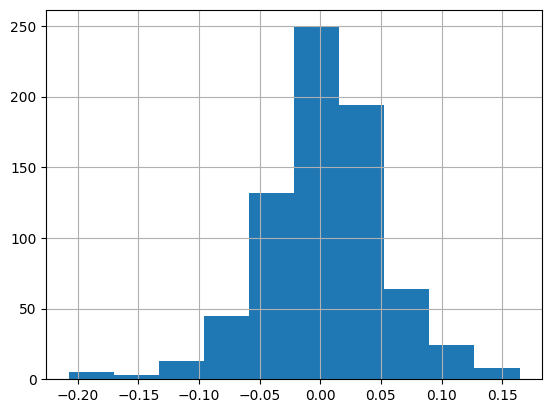

In [13]:
panel['y_excess_lead'].hist()



# Adding context variables

1. **Price-based / Technical features**

These come straight from the ETF’s own return history:

-   Lagged returns (1-week, 2-week, 4-week, etc.)
-   Momentum: rolling cumulative returns over 3m, 6m, 12m.
-   Volatility measures: rolling standard deviation (e.g. 4w, 12w).
-   Drawdown: max decline from recent peak.
-   Skew/kurtosis of rolling returns.
-   Moving averages (20-day, 50-day, 200-day) and crossovers.
-   RSI / stochastic oscillators (basic technicals).

2. **Cross-sectional / Fundamental ETF descriptors**

Even though ETFs don’t have classic accounting statements, they inherit factor exposures:

-   Asset class tags (equity, fixed income, REIT, emerging markets, etc.).
-   Region/country exposures (developed, EM, Asia, US).
-   Style (value vs growth, small vs large cap).
-   Duration / credit exposure for bond ETFs (BYLD, HYEM, VWOB).
-   Sector tilts (VNQ/VNQI = real estate). 

These can be encoded as categorical one-hot vectors or embeddings.

3. **Market-wide / Macro features**

All ETFs are affected by common risk factors:

-   Equity market index returns (S&P 500, MSCI World).
-   Bond yields: 2y, 10y Treasury yields, yield curve slope.
-   Credit spreads: investment grade vs HY spread.
-   FX indices (USD index).
-   Commodities: oil, gold.
-   Volatility index (VIX).
-   Inflation surprise indices, unemployment, PMI (if you want to bring in economic releases).

These are typically aligned to the same horizon as your ETF panel (weekly).


4. **Calendar / Regime features**

Markets behave differently under certain regimes:

-   Month of year / quarter of year (seasonality effects).

-   Week-of-month / day-of-week (if you go daily).

-   Recession vs expansion flags (NBER or proxy).

-   Fed meeting weeks, earnings season flags.

-   Volatility regime (low/high VIX).

# 1. Price based features

**Note**
All features are computed on resampled weekly closes to match your Friday→Friday target and avoid look-ahead.

-   Momentum features (e.g., mom_13w) are cumulative: 
(1 + 𝑟) ^ 13 −1

-   Volatility uses weekly returns’ std, not price std.

-   RSI uses Wilder smoothing on weekly price changes (rsi_14w).

-   Expect NaNs at the beginning for windows like 26 or 52 weeks—normal. Inner-joining with the target naturally trims the very early warm-up period.


### 📊 Price-Based Feature Definitions

| Feature       | Definition                                                                                   | Lookback Window            |
|---------------|-----------------------------------------------------------------------------------------------|----------------------------|
| **ret_1w**    | Simple return over the past 1 week.                                                           | 1 week                     |
| **ret_2w**    | Cumulative return over the past 2 weeks.                                                      | 2 weeks                    |
| **ret_4w**    | Cumulative return over the past 4 weeks (~1 month).                                           | 4 weeks                    |
| **mom_13w**   | Momentum: cumulative return over the past 13 weeks (~quarter).                                | 13 weeks (~3 months)       |
| **mom_26w**   | Momentum: cumulative return over the past 26 weeks (~half year).                              | 26 weeks (~6 months)       |
| **mom_52w**   | Momentum: cumulative return over the past 52 weeks (~1 year).                                 | 52 weeks (~12 months)      |
| **vol_4w**    | Rolling standard deviation of weekly returns.                                                 | 4 weeks                    |
| **vol_12w**   | Rolling standard deviation of weekly returns.                                                 | 12 weeks (~3 months)       |
| **vol_26w**   | Rolling standard deviation of weekly returns.                                                 | 26 weeks (~6 months)       |
| **dd_26w**    | Current drawdown relative to rolling maximum price (how far below recent peak).               | 26 weeks (~6 months)       |
| **ma_4w**     | 4-week simple moving average of price.                                                        | 4 weeks                    |
| **ma_12w**    | 12-week simple moving average of price.                                                       | 12 weeks (~3 months)       |
| **ma_26w**    | 26-week simple moving average of price.                                                       | 26 weeks (~6 months)       |
| **px_ma4_gap**  | % difference between price and its 4-week moving average.                                    | 4 weeks                    |
| **px_ma12_gap** | % difference between price and its 12-week moving average.                                   | 12 weeks (~3 months)       |
| **px_ma26_gap** | % difference between price and its 26-week moving average.                                   | 26 weeks (~6 months)       |
| **skew_12w**  | Skewness of weekly returns distribution (asymmetry).                                          | 12 weeks (~3 months)       |
| **kurt_12w**  | Excess kurtosis of weekly returns distribution (fat tails vs. normal).                        | 12 weeks (~3 months)       |
| **rsi_14w**   | Relative Strength Index (RSI) based on weekly closes. >70 = “overbought”, <30 = “oversold”.   | 14 weeks                   |

In [ ]:
def _rolling_cumret(r: pd.Series, win: int) -> pd.Series:
    return (1.0 + r).rolling(window=win, min_periods=win).apply(np.prod, raw=True) - 1.0

def _rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    delta = prices.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))

def _resample_prices(prices_wide: pd.DataFrame, freq: str) -> pd.DataFrame:
    """Resample to period-end closes (e.g., 'W-FRI' for weekly, 'BM' for monthly)."""
    return prices_wide.resample(freq).last().dropna(how="all")

def compute_price_features_for_one(px: pd.Series, cfg: dict, suffix: str) -> pd.DataFrame:
    """
    Compute price features on a resampled price series (weekly or monthly).
    cfg contains integer window sizes measured in *resampled periods*.
    suffix is 'w' or 'm' for column names.
    """
    s = px.dropna()
    ret = s.pct_change()

    feat = pd.DataFrame(index=s.index)

    # Returns / momentum
    feat[f"ret_1{suffix}"] = ret
    for k in cfg["ret_multi"]:
        feat[f"ret_{k}{suffix}"] = _rolling_cumret(ret, k)
    for k in cfg["mom"]:
        feat[f"mom_{k}{suffix}"] = _rolling_cumret(ret, k)

    # Volatility
    for k in cfg["vol"]:
        feat[f"vol_{k}{suffix}"] = ret.rolling(k, min_periods=k).std()

    # Drawdown vs rolling max
    ddw = cfg["dd_window"]
    rolling_max = s.rolling(ddw, min_periods=ddw).max()
    feat[f"dd_{ddw}{suffix}"] = (s / rolling_max) - 1.0

    # Moving averages & gaps
    for k in cfg["ma"]:
        ma = s.rolling(k, min_periods=k).mean()
        feat[f"ma_{k}{suffix}"] = ma
        feat[f"px_ma{k}_gap"] = (s / ma) - 1.0  # unitless gap; suffix not critical

    # Higher moments
    sk = cfg["sk_kurt_window"]
    feat[f"skew_{sk}{suffix}"] = ret.rolling(sk, min_periods=sk).skew()
    feat[f"kurt_{sk}{suffix}"] = ret.rolling(sk, min_periods=sk).kurt()

    # RSI
    rsi_p = cfg["rsi_period"]
    feat[f"rsi_{rsi_p}{suffix}"] = _rsi(s, period=rsi_p)

    return feat

def build_price_features_panel(tickers, start, end=None, horizon="weekly") -> pd.DataFrame:
    """
    Returns long panel: date, asset_id, price features.
    Resampling + window sizes adapt to `horizon`.
    """
    prices = fetch_prices(tickers, start, end)

    if horizon.lower() == "weekly":
        freq, suffix = "W-FRI", "w"
        cfg = dict(
            ret_multi=[2, 4],
            mom=[13, 26, 52],
            vol=[4, 12, 26],
            dd_window=26,
            ma=[4, 12, 26],
            sk_kurt_window=12,
            rsi_period=14,  # 14 weeks
        )
    elif horizon.lower() == "monthly":
        freq, suffix = "BM", "m"
        cfg = dict(
            ret_multi=[2, 3],     # 1m, 2m, 3m
            mom=[3, 6, 12],       # 3m, 6m, 12m momentum
            vol=[3, 6, 12],       # 3/6/12-month realized vol
            dd_window=12,         # 12-month rolling max
            ma=[3, 6, 12],        # 3/6/12-month MAs
            sk_kurt_window=6,     # 6-month window for higher moments
            rsi_period=9,         # 9-month RSI (or 14 if you prefer)
        )
    else:
        raise ValueError("horizon must be 'weekly' or 'monthly'")

    px_resampled = _resample_prices(prices, freq=freq)

    rows = []
    for tk in px_resampled.columns:
        f = compute_price_features_for_one(px_resampled[tk], cfg=cfg, suffix=suffix)
        f = f.rename_axis("date").reset_index()
        f.insert(1, "asset_id", tk)
        rows.append(f)

    return (
        pd.concat(rows, axis=0)
          .sort_values(["date", "asset_id"])
          .reset_index(drop=True)
    )

# def build_dataset_with_features(tickers, start, end=None, horizon="weekly", fixed_h_days=5) -> pd.DataFrame:
#     target_panel = build_long_panel(tickers, start, end, horizon=horizon, fixed_h_days=fixed_h_days)
#     feat_panel   = build_price_features_panel(tickers, start, end, horizon=horizon)
#     df = pd.merge(target_panel, feat_panel, on=["date", "asset_id"], how="inner")
#     return df


,date,asset_id,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,...,dd_12m,ma_3m,px_ma3_gap,ma_6m,px_ma6_gap,ma_12m,px_ma12_gap,skew_6m,kurt_6m,rsi_9m
0,2020-01-31,AVEM,-0.0443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-31,BYLD,0.00332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-31,ESGD,-0.0727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-31,HYEM,-0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-31,IEF,0.0284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,2025-07-31,SNPE,0.0227,0.0253,0.0847,0.145,0.145,0.0539,0.134,0.0183,...,0.0,54.8,0.0355,52.9,0.0721,52.8,0.0742,-0.295,-1.2,71.5
733,2025-07-31,VBK,0.0311,0.0197,0.072,0.141,0.141,-0.0293,0.0863,0.0228,...,-0.0597,2.74e+02,0.0297,2.66e+02,0.0627,2.71e+02,0.0406,-0.204,-1.97,59.8
734,2025-07-31,VNQ,0.0314,0.000898,0.00779,0.0191,0.0191,0.00431,0.0242,0.00518,...,-0.0646,88.9,0.00288,89.3,-0.00183,90.4,-0.0139,0.283,-0.386,54.2
735,2025-07-31,VNQI,0.0556,-0.0202,0.0238,0.0541,0.0541,0.127,0.117,0.034,...,-0.0202,45.2,0.000885,43.2,0.0467,42.4,0.0671,0.0258,-1.16,64.8


2. **Cross-sectional / Fundamental ETF descriptors**

In [15]:
# get etf categories 
categories = {}

for asset in TICKERS:
    ticker = yf.Ticker(asset)
    info = ticker.info
    category = info.get('category', 'Unknown')
    categories[asset] = category
categories

{'AVEM': 'Diversified Emerging Mkts',
 'BYLD': 'Multisector Bond',
 'ESGD': 'Foreign Large Blend',
 'HYEM': 'Emerging Markets Bond',
 'IEF': 'Long Government',
 'ISCF': 'Foreign Small/Mid Blend',
 'SNPE': 'Large Blend',
 'VBK': 'Small Growth',
 'VNQ': 'Real Estate',
 'VNQI': 'Global Real Estate',
 'XMMO': 'Mid-Cap Blend'}

In [16]:
fundamentals = {}

asset_class = {'AVEM': 'Equity',
 'AVES': 'Equity',
 'BYLD': 'Fixed Income',
 'ESGD': 'Equity',
 'HYEM': 'Fixed Income',
 'IEF': 'Fixed Income',
 'ISCF': 'Equity',
 'SNPE': 'Equity',
 'VBK': 'Equity',
 'VNQ': 'Real Estate',
 'VNQI': 'Real Estate',
 'VWOB': 'Fixed Income',
 'XMMO': 'Equity'}

region = {'AVEM': 'International',
 'AVES': 'International',
 'BYLD': 'US',
 'ESGD': 'International',
 'HYEM': 'International',
 'IEF': 'US',
 'ISCF': 'International',
 'SNPE': 'US',
 'VBK': 'US',
 'VNQ': 'US',
 'VNQI': 'International',
 'VWOB': 'International',
 'XMMO': 'US'}

fundamentals['asset_class'] = asset_class
fundamentals['region'] = region



# etf = yf.Ticker('ESGD')

# fd = etf.funds_data              # or: etf.get_funds_data()
# fd.sector_weightings             # -> dict of sector -> weight (0–1)
# fd.top_holdings                  # -> DataFrame of top holdings (symbol, name, weight)
# fd.equity_holdings               # -> summary ratios (P/E, P/B, etc.)
# fd.asset_classes                 # -> {'stocks': ..., 'bonds': ...}
# fd.__dict__

3. **Market-wide / Macro features**


| **Feature** | **Definition** | **Lookback Window** |
|-------------|----------------|---------------------|
| `spy_ret_1w`, `acwi_ret_1w`, `veu_ret_1w`, `eem_ret_1w` | Weekly return of broad equity indices (US, Global, DM ex-US, EM) | 1 week |
| `*_mom_4w`, `*_mom_13w`, `*_mom_26w` | Cumulative momentum return over past 4, 13, or 26 weeks | 4w, 13w, 26w |
| `*_vol_12w` | Standard deviation of weekly returns | 12 weeks |
| `*_dd_52w` | Drawdown vs. rolling 52-week high | 52 weeks |
| `vix_level` | CBOE VIX index level (weekly last) | — |
| `vix_chg_1w` | Weekly % change in VIX | 1 week |
| `vix_z_52w` | Z-score of VIX relative to trailing mean/stdev | 52 weeks |
| `usd_ret_1w`, `oil_ret_1w`, `gold_ret_1w`, `copper_ret_1w` | Weekly return of dollar proxy (UUP) and commodities (WTI, Gold, Copper) | 1 week |
| `usd_mom_13w`, `oil_mom_13w`, `gold_mom_13w`, `copper_mom_13w` | 13-week cumulative return (momentum) | 13 weeks |
| `usd_mom_26w`, `oil_mom_26w`, `gold_mom_26w`, `copper_mom_26w` | 26-week cumulative return (momentum) | 26 weeks |
| `*_vol_12w` (for USD/commodities) | Standard deviation of weekly returns | 12 weeks |
| `hy_ig_rel_1w` | Weekly relative return: High Yield (HYG) vs IG Corp (LQD) | 1 week |
| `hy_ig_rel_13w`, `hy_ig_rel_26w` | Rolling relative performance HY vs IG | 13w, 26w |
| `emb_ief_rel_1w` | Weekly relative return: EM sovereign bonds (EMB) vs Treasuries (IEF) | 1 week |
| `emb_ief_rel_13w`, `emb_ief_rel_26w` | Rolling relative performance EM vs Treasuries | 13w, 26w |
| `t10y_level`, `t05y_level`, `t02y_level` | Yield level (decimal, not %) for 10y, 5y, 3m Treasuries | — |
| `t10y_chg_bp_1w`, `t05y_chg_bp_1w` | Weekly change in 10y / 5y yield (basis points) | 1 week |
| `slope_10y_3m`, `slope_10y_3m_bp` | 10y minus 3m term spread (decimal, bp) | — |
| `slope_chg_bp_4w` | 4-week change in 10y–3m slope (basis points) | 4 weeks |
| `slope_z_104w` | Z-score of 10y–3m slope vs trailing 2-year distribution. It tells you how extreme the yield curve is compared to recent history | 104 weeks |
| `curve_proxy`, `curve_proxy_bp` | Proxy curvature = (10y – 2×5y + 3m), in decimal and bp | — |

In [20]:
"""
macro_features.py

Build market-wide macro features to merge into your ETF dataset.
- Uses daily market proxies via yfinance, resampled to a weekly (Friday) calendar.
- All features are computed with information available as of each week-end date (no look-ahead).
- Safe to inner-join on 'date' with your existing weekly dataset.

Dependencies:
    pip install yfinance pandas numpy

Example:
    from macro_features import build_macro_features, merge_macro_features

    macro = build_macro_features(start="2023-01-01", end=None, freq="W-FRI")
    df_final = merge_macro_features(df_base, macro)  # df_base must have a 'date' column
"""
from __future__ import annotations
import numpy as np
import pandas as pd
import yfinance as yf
from typing import Dict, List, Optional

# ---------------------------
# Utilities
# ---------------------------

def _ensure_datetime_index(df: pd.DataFrame | pd.Series) -> pd.DataFrame | pd.Series:
    out = df.copy()
    out.index = pd.to_datetime(out.index)
    return out

def _fetch_adj_close(tickers: List[str], start: str, end: Optional[str] = None) -> pd.DataFrame:
    """
    Robustly fetch Adjusted Close for multiple tickers using yfinance.
    Returns wide DataFrame with columns = tickers, index = trading days.
    """
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        interval="1d",
        group_by="ticker",
        auto_adjust=False,
        progress=False,
        threads=True,
    )
    # Normalize shape across yfinance versions
    if isinstance(px.columns, pd.MultiIndex):
        cols = []
        for tk in tickers:
            if (tk, "Adj Close") in px.columns:
                cols.append(px[(tk, "Adj Close")].rename(tk))
            elif (tk, "Close") in px.columns:
                cols.append(px[(tk, "Close")].rename(tk))
        out = pd.concat(cols, axis=1)
    else:
        # Single ticker case
        base = "Adj Close" if "Adj Close" in px.columns else "Close"
        out = px[[base]]
        out.columns = [tickers[0]]
    out = _ensure_datetime_index(out).sort_index().dropna(how="all")
    return out

def _weekly_last(df: pd.DataFrame, freq: str = "W-FRI") -> pd.DataFrame:
    """Resample to weekly (Friday) closes to match your target calendar."""
    return df.resample(freq).last().dropna(how="all")

def _pct_change(s: pd.Series, periods: int = 1) -> pd.Series:
    return s.pct_change(periods=periods)

def _rolling_cumret(r: pd.Series, win: int) -> pd.Series:
    """(1+r).rolling(win).apply(prod)-1; robust to NaNs."""
    return (1.0 + r).rolling(window=win, min_periods=win).apply(np.prod, raw=True) - 1.0

def _zscore(s: pd.Series, win: int) -> pd.Series:
    m = s.rolling(win, min_periods=win).mean()
    v = s.rolling(win, min_periods=win).std()
    return (s - m) / v.replace(0, np.nan)

# --- horizon config ---
def _macro_cfg(horizon: str):
    h = horizon.lower()
    if h == "weekly":
        return dict(
            freq="W-FRI", suffix="w",
            mom=[4,13,26], vol=[12], dd=52, vix_z=52,
            hy_ig=[13,26], emb_ief=[13,26],
            rate_chg=1, slope_chg=4, slope_z=104  # 104w ~ 2y
        )
    elif h == "monthly":
        return dict(
            freq="BM", suffix="m",
            mom=[3,6,12], vol=[6,12], dd=12, vix_z=24,
            hy_ig=[3,6], emb_ief=[3,6],
            rate_chg=1, slope_chg=3, slope_z=24     # 24m ~ 2y
        )
    else:
        raise ValueError("horizon must be 'weekly' or 'monthly'")

def _resample_last(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    return df.resample(freq).last().dropna(how="all")

# ---------------------------
# Macro universe (proxies)
# ---------------------------
MACRO_TICKERS: Dict[str, str] = {
    # Equity market and volatility
    "spy": "SPY",        # US equity market proxy
    "acwi": "ACWI",      # Global equity
    "eem": "EEM",        # EM equity proxy
    "veu": "VEU",        # DM ex-US equity proxy
    "vix": "^VIX",       # Implied vol (level index)

    # US Rates (Yahoo yields are in percent; ^TNX is 10x yield)
    "t10y": "^TNX",      # 10Y UST yield (%*10)
    "t05y": "^FVX",      # 5Y UST yield (%*10)
    "t03m": "^IRX",      # 3-month T-bill

    # Dollar
    "usd": "UUP",        # DXY proxy (ETF)

    # Commodities
    "oil": "CL=F",       # WTI front month futures
    "gold": "GC=F",      # Gold futures
    "copper": "HG=F",    # Copper futures

    # Credit proxies (spreads via relative returns)
    "hyg": "HYG",        # US High Yield
    "lqd": "LQD",        # US IG Corp
    "emb": "EMB",        # EM Sovereign (USD)
    "ief": "IEF",        # 7-10Y Treasuries (duration-matched)
}

# ---------------------------
# Feature engineering
# ---------------------------


def _rate_from_yahoo_yield(y: pd.Series, code: str) -> pd.Series:
    """
    Convert Yahoo Finance Treasury yield tickers to DECIMAL yields.
    - ^TNX and ^FVX are quoted as percent * 10 (e.g., 45.6 => 4.56% => 0.0456).
    - ^IRX is a percent (e.g., 5.30 => 5.30% => 0.0530).
    Returns a decimal (e.g., 0.0456).
    """
    s = y.astype(float)
    if code in ("^TNX", "^FVX"):
        return (s / 10.0) / 100.0
    elif code in ("^IRX",):
        return s / 100.0
    else:
        return s / 100.0

def _build_levels_and_returns(px_res: pd.DataFrame, cfg) -> pd.DataFrame:
    feat = pd.DataFrame(index=px_res.index)
    sfx = cfg["suffix"]

    for label in ["spy","acwi","veu","eem"]:
        if label in px_res:
            r = px_res[label].pct_change()
            feat[f"{label}_ret_1{sfx}"] = r
            for k in cfg["mom"]:
                feat[f"{label}_mom_{k}{sfx}"] = (1+r).rolling(k, min_periods=k).apply(np.prod, raw=True) - 1.0
            for k in cfg["vol"]:
                feat[f"{label}_vol_{k}{sfx}"] = r.rolling(k, min_periods=k).std()
            rolling_max = px_res[label].rolling(cfg["dd"], min_periods=cfg["dd"]).max()
            feat[f"{label}_dd_{cfg['dd']}{sfx}"] = (px_res[label] / rolling_max) - 1.0

    if "vix" in px_res:
        vix = px_res["vix"]
        feat["vix_level"] = vix
        feat[f"vix_chg_1{sfx}"] = vix.pct_change()
        feat[f"vix_z_{cfg['vix_z']}{sfx}"] = (vix - vix.rolling(cfg["vix_z"]).mean())/vix.rolling(cfg["vix_z"]).std()

    for label in ["usd","oil","gold","copper"]:
        if label in px_res:
            r = px_res[label].pct_change()
            feat[f"{label}_ret_1{sfx}"] = r
            for k in cfg["mom"]:
                feat[f"{label}_mom_{k}{sfx}"] = (1+r).rolling(k, min_periods=k).apply(np.prod, raw=True) - 1.0
            for k in cfg["vol"]:
                feat[f"{label}_vol_{k}{sfx}"] = r.rolling(k, min_periods=k).std()

    if {"hyg","lqd"}.issubset(px_res.columns):
        rel = (1+px_res["hyg"].pct_change())/(1+px_res["lqd"].pct_change()) - 1.0
        feat[f"hy_ig_rel_1{sfx}"] = rel
        for k in cfg["hy_ig"]:
            feat[f"hy_ig_rel_{k}{sfx}"] = (1+rel).rolling(k, min_periods=k).apply(np.prod, raw=True) - 1.0

    if {"emb","ief"}.issubset(px_res.columns):
        rel = (1+px_res["emb"].pct_change())/(1+px_res["ief"].pct_change()) - 1.0
        feat[f"emb_ief_rel_1{sfx}"] = rel
        for k in cfg["emb_ief"]:
            feat[f"emb_ief_rel_{k}{sfx}"] = (1+rel).rolling(k, min_periods=k).apply(np.prod, raw=True) - 1.0

    return feat

def _build_rates_features(yields_res: pd.DataFrame, cfg) -> pd.DataFrame:
    feat = pd.DataFrame(index=yields_res.index)
    sfx = cfg["suffix"]; chg = cfg["rate_chg"]

    if "t10y" in yields_res:
        feat["t10y_level"] = yields_res["t10y"]
        feat[f"t10y_chg_bp_1{sfx}"] = yields_res["t10y"].diff(chg) * 1e4

    if "t05y" in yields_res:
        feat["t05y_level"] = yields_res["t05y"]
        feat[f"t05y_chg_bp_1{sfx}"] = yields_res["t05y"].diff(chg) * 1e4

    # 10y - 3m slope
    if {"t10y","t03m"}.issubset(yields_res.columns):
        slope = yields_res["t10y"] - yields_res["t03m"]
        feat[f"slope_10y_3m"] = slope
        feat[f"slope_10y_3m_bp"] = slope * 1e4
        feat[f"slope_chg_{cfg['slope_chg']}{sfx}"] = slope.diff(cfg["slope_chg"])
        feat[f"slope_chg_bp_{cfg['slope_chg']}{sfx}"] = slope.diff(cfg["slope_chg"]) * 1e4
        feat[f"slope_z_{cfg['slope_z']}{sfx}"] = (slope - slope.rolling(cfg["slope_z"]).mean())/slope.rolling(cfg["slope_z"]).std()

    if {"t10y","t05y","t03m"}.issubset(yields_res.columns):
        curv = yields_res["t10y"] - 2.0*yields_res["t05y"] + yields_res["t03m"]
        feat["curve_proxy"] = curv
        feat["curve_proxy_bp"] = curv * 1e4

    return feat

# ---------------------------
# Public API
# ---------------------------

def build_macro_features(start: str, end: str | None = None, horizon: str = "weekly") -> pd.DataFrame:
    cfg = _macro_cfg(horizon)
    # price-like
    price_like = ["spy","acwi","eem","veu","vix","usd","oil","gold","copper","hyg","lqd","emb","ief"]
    px = _fetch_adj_close([MACRO_TICKERS[k] for k in price_like], start, end)
    px = px.rename(columns={MACRO_TICKERS[k]: k for k in price_like if MACRO_TICKERS[k] in px.columns})
    px_res = _resample_last(px, cfg["freq"])

    # yields (decimal)
    yield_keys = ["t10y","t05y","t03m"]
    yld = _fetch_adj_close([MACRO_TICKERS[k] for k in yield_keys], start, end)
    yld_dec = pd.DataFrame(index=yld.index)
    for key in yield_keys:
        tk = MACRO_TICKERS[key]
        if tk in yld.columns:
            yld_dec[key] = _rate_from_yahoo_yield(yld[tk], tk)
    yld_res = _resample_last(yld_dec, cfg["freq"])

    feat = pd.concat([_build_levels_and_returns(px_res, cfg),
                      _build_rates_features(yld_res, cfg)], axis=1).sort_index()
    return feat.reset_index().rename(columns={"index":"date"})

def merge_macro_features(df_base: pd.DataFrame, macro: pd.DataFrame, how: str = "inner") -> pd.DataFrame:
    """
    Merge macro feature table into your existing LONG dataset on 'date'.
    Assumes df_base has a 'date' column in datetime (or parseable) format.
    """
    out = df_base.copy()
    if not np.issubdtype(out["date"].dtype, np.datetime64):
        out["date"] = pd.to_datetime(out["date"])
    macro2 = macro.copy()
    if not np.issubdtype(macro2["date"].dtype, np.datetime64):
        macro2["date"] = pd.to_datetime(macro2["date"])
    merged = pd.merge(out, macro2, on="date", how=how)
    return merged

In [ ]:
# def build_dataset_with_features(tickers, fundamentals, start, end=None, horizon="monthly", fixed_h_days=5) -> pd.DataFrame:
#     """
#     Build the dataset with output, price features, and macro features.
    
#     """
#     panel_y = build_long_panel(tickers, start, end, horizon=horizon, fixed_h_days=fixed_h_days)
#     # Price-based features
#     panel_x_price = build_price_features_panel(tickers, start, end, horizon=horizon)
    
#     df = pd.merge(panel_y, panel_x_price, on=["date", "asset_id"], how="inner")
#     # Macro features
#     macro = build_macro_features(start=START, end=END, horizon="monthly")
#     macro.rename(columns={"Date": "date"}, inplace=True)
    
#     dataset = merge_macro_features(df, macro, how="inner")
#     # Map the dictionaries to create new columns
#     dataset['asset_class'] = dataset['asset_id'].map(fundamentals['asset_class'])
#     dataset['region'] = dataset['asset_id'].map(fundamentals['region'])
    
#     return dataset


In [ ]:
# # Target only (what you already do)
# panel_y = build_long_panel(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)

# # Price-based features
# panel_x_price = build_price_features_panel(TICKERS, START, END, horizon=HORIZON)

# # Macro features
# macro = build_macro_features(start=START, end=END, horizon="monthly")
# macro.rename(columns={"Date": "date"}, inplace=True)


# # merged dataset (X + y)
# dataset = build_dataset_with_features(TICKERS, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)
# dataset = merge_macro_features(dataset, macro, how="inner")
# dataset.head()

# dataset = build_dataset_with_features(TICKERS, fundamentals, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)
# dataset.head()

,date,asset_id,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,...,t05y_chg_bp_1m,slope_10y_3m,slope_10y_3m_bp,slope_chg_3m,slope_chg_bp_3m,slope_z_24m,curve_proxy,curve_proxy_bp,asset_class,region
0,2020-01-31,AVEM,-0.0443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0136,-1.36e+02,NaN,NaN,NaN,0.014,1.4e+02,Equity,International
1,2020-01-31,BYLD,0.00332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0136,-1.36e+02,NaN,NaN,NaN,0.014,1.4e+02,Fixed Income,US
2,2020-01-31,ESGD,-0.0727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0136,-1.36e+02,NaN,NaN,NaN,0.014,1.4e+02,Equity,International
3,2020-01-31,HYEM,-0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0136,-1.36e+02,NaN,NaN,NaN,0.014,1.4e+02,Fixed Income,International
4,2020-01-31,IEF,0.0284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.0136,-1.36e+02,NaN,NaN,NaN,0.014,1.4e+02,Fixed Income,US


# 📅 Calendar & Regime Feature Engineering


| Feature                  | Definition                                                                                  |
|---------------------------|----------------------------------------------------------------------------------------------|
| **month**                | Month of year (1–12). Captures seasonal effects such as “January effect.”                   |
| **quarter**              | Quarter of year (1–4). Useful for fiscal and earnings cycles.                                |
| **week_of_month**        | Which week of the month the date falls into (1st, 2nd, 3rd, 4th, etc.).                      |
| **recession_flag**       | 1 if within known NBER recession periods (e.g., 2020 COVID recession), else 0.              |
| **recession_proxy**      | 1 if yield curve slope (10y – 3m) is negative (inversion proxy for recession), else 0.       |
| **fed_meeting_week**     | 1 if the week coincides with a scheduled FOMC meeting, else 0.                               |
| **earnings_season**      | 1 if within the first ~6 weeks of a quarter (bulk of corporate earnings releases).           |
| **earnings_season_quarters** | 1 if the month is Jan/Apr/Jul/Oct (quarters with heavy earnings concentration).           |
| **vix_high**             | 1 if VIX level is above its median (indicating high-volatility regime), else 0.              |
| **vix_regime**           | Categorization of VIX level into “low,” “medium,” or “high” based on quantile cutoffs.       |

In [30]:
def add_calendar_regime_features(df: pd.DataFrame, horizon: str = "weekly") -> pd.DataFrame:
    """
    Add calendar & regime features aligned to the modeling horizon.
    Assumes df['date'] is the prediction timestamp (period end):
      - weekly horizon: Friday dates (W-FRI)
      - monthly horizon: business month-end (BM)
    """
    df = df.copy()
    if not np.issubdtype(df["date"].dtype, np.datetime64):
        df["date"] = pd.to_datetime(df["date"])

    h = horizon.lower()
    if h not in {"weekly", "monthly"}:
        raise ValueError("horizon must be 'weekly' or 'monthly'")

    # ----------------
    # Calendar fields
    # ----------------
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter

    if h == "weekly":
        # Week-of-month = 1..5 based on the Friday's calendar day
        df["week_of_month"] = df["date"].apply(lambda d: (d.day - 1) // 7 + 1)
    else:
        # For monthly, week_of_month is not meaningful; provide a stub (optional)
        df["week_of_month"] = pd.NA

    # ----------------
    # Recession flags
    # ----------------
    # NBER recessions (example window; update as needed)
    nber_recessions = [
        ("2020-02-01", "2020-04-30"),
        # add more ranges if you include earlier periods
    ]
    df["recession_flag"] = 0
    for start, end in nber_recessions:
        m = (df["date"] >= pd.to_datetime(start)) & (df["date"] <= pd.to_datetime(end))
        df.loc[m, "recession_flag"] = 1

    # Yield-curve inversion proxy (works for both horizons if present)
    if "slope_10y_3m" in df.columns:
        df["recession_proxy"] = (df["slope_10y_3m"] < 0).astype(int)
    else:
        df["recession_proxy"] = pd.NA

    # ----------------
    # FOMC meetings
    # ----------------
    # Keep this list fresh each year
    fomc_meetings = pd.to_datetime([
        # 2023
        "2023-01-31","2023-03-21","2023-05-02","2023-06-13",
        "2023-07-25","2023-09-19","2023-10-31","2023-12-12",
        # 2024
        "2024-01-30","2024-03-19","2024-04-30","2024-06-11",
        "2024-07-30","2024-09-17","2024-11-06","2024-12-17",
        # 2025 (partial list you provided)
        "2025-01-29","2025-03-19","2025-05-07","2025-06-18","2025-07-30",
        # add the remaining 2025 meetings when confirmed
        # "2025-09-17","2025-10-29","2025-12-10"
    ])

    if h == "weekly":
        # Map meetings to their W-FRI period and compare to df's weekly period
        meet_weeks = fomc_meetings.to_period("W-FRI")
        df_weeks = df["date"].dt.to_period("W-FRI")
        df["fed_meeting_week"] = df_weeks.isin(set(meet_weeks)).astype(int)
    else:
        # Monthly: flag months that contain a meeting
        meet_months = fomc_meetings.to_period("M")
        df_months = df["date"].dt.to_period("M")
        df["fed_meeting_week"] = df_months.isin(set(meet_months)).astype(int)  # keep column name for compatibility

    # ----------------
    # Earnings season
    # ----------------
    # Proxy: Jan/Apr/Jul/Oct tend to be earnings-heavy
    if h == "weekly":
        # first 6 weeks of earnings-heavy months (if your index is W-FRI)
        is_earn_month = df["month"].isin([1, 4, 7, 10])
        df["earnings_season"] = (is_earn_month & (df["week_of_month"].astype("Int64") <= 6)).fillna(False)
        df["earnings_season_quarters"] = is_earn_month.astype(int)
    else:
        # monthly: simply flag those months
        is_earn_month = df["month"].isin([1, 4, 7, 10])
        df["earnings_season"] = is_earn_month.astype(int)
        df["earnings_season_quarters"] = is_earn_month.astype(int)

    # ----------------
    # VIX regimes
    # ----------------
    if "vix_level" in df.columns:
        # median split is horizon-agnostic; optionally make it rolling
        vix_median = df["vix_level"].median()
        df["vix_high"] = (df["vix_level"] > vix_median).astype(int)
        try:
            df["vix_regime"] = pd.qcut(df["vix_level"], q=3, labels=["low", "medium", "high"])
        except Exception:
            # if not enough unique values for qcut
            df["vix_regime"] = pd.Series(["medium"] * len(df), index=df.index, dtype="category")
    else:
        df["vix_high"] = pd.NA
        df["vix_regime"] = pd.Series(pd.NA, index=df.index, dtype="object")

    return df


In [32]:
def build_dataset_with_features(tickers, fundamentals, start, end=None, horizon="monthly", fixed_h_days=5) -> pd.DataFrame:
    """
    Build the dataset with output, price features, and macro features.
    
    """
    panel_y = build_long_panel(tickers, start, end, horizon=horizon, fixed_h_days=fixed_h_days)
    # Price-based features
    panel_x_price = build_price_features_panel(tickers, start, end, horizon=horizon)
    
    df = pd.merge(panel_y, panel_x_price, on=["date", "asset_id"], how="inner")
    # Macro features
    macro = build_macro_features(start=START, end=END, horizon="monthly")
    macro.rename(columns={"Date": "date"}, inplace=True)
    
    dataset = merge_macro_features(df, macro, how="inner")
    # Map the dictionaries to create new columns
    dataset['asset_class'] = dataset['asset_id'].map(fundamentals['asset_class'])
    dataset['region'] = dataset['asset_id'].map(fundamentals['region'])
    dataset = add_calendar_regime_features(dataset)
    
    return dataset

In [33]:
dataset = build_dataset_with_features(TICKERS, fundamentals, START, END, horizon=HORIZON, fixed_h_days=FIXED_H_DAYS)
dataset.head()

,date,asset_id,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,2020-01-31,AVEM,-0.0443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,5,0,1,0,True,1,0,medium
1,2020-01-31,BYLD,0.00332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,5,0,1,0,True,1,0,medium
2,2020-01-31,ESGD,-0.0727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,5,0,1,0,True,1,0,medium
3,2020-01-31,HYEM,-0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,5,0,1,0,True,1,0,medium
4,2020-01-31,IEF,0.0284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,5,0,1,0,True,1,0,medium


In [14]:
# import base64
# import os

# import numpy as np
# import pandas as pd
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots


# def histogram_matrix(data: pd.DataFrame) -> go.Figure:
#     """Plot the distribution of variables in dataset."""
#     # Create subplots with up to 4 variables per row
#     data = data.copy()
#     max_vars_per_row = 4
#     num_vars = len(data.columns)
#     num_rows = (num_vars + max_vars_per_row - 1) // max_vars_per_row
#     height = 300 if num_rows == 1 else 200 * num_rows
#     fig = make_subplots(rows=num_rows, cols=max_vars_per_row, subplot_titles=data.columns)

#     # Populate subplots with histograms
#     for i, column in enumerate(data.columns, start=1):
#         row = (i - 1) // max_vars_per_row + 1
#         col = (i - 1) % max_vars_per_row + 1
#         trace = go.Histogram(x=data[column], name=column, nbinsx=10, marker=dict(color="#33608D"))
#         fig.add_trace(trace, row=row, col=col)

#     # Update layout
#     fig.update_layout(
#         title="",
#         title_x=0.5,
#         height=height,
#         width=200 * max_vars_per_row,
#         showlegend=False,
#         template="plotly_white",
#         margin={"l": 25, "r": 25, "t": 25, "b": 25},
#     )

#     return fig

In [15]:
# # Loop through the columns of the dataset in chunks of 10
# for i in range(0, len(dataset.columns), 10):
#     # Select a subset of 10 columns
#     subset = dataset.iloc[:, i:i+10]
    
#     # Render the histogram matrix for the subset
#     fig = histogram_matrix(subset)
#     fig.show()

In [34]:
# Step 1: Compute the correlation matrix
correlation_matrix = dataset.select_dtypes("number").corr()
correlation_matrix

,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,vol_12m,...,curve_proxy,curve_proxy_bp,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season_quarters,vix_high
y_excess_lead,1.0,-0.0482,-0.15,-0.0296,-0.0296,0.0433,0.0149,0.0378,0.051,0.0767,...,0.0141,0.0141,0.132,0.144,0.165,-0.0338,-0.122,0.105,0.117,0.0679
ret_1m,-0.0482,1.0,0.671,0.439,0.439,0.396,0.265,0.223,0.152,0.093,...,0.0693,0.0693,0.13,0.166,0.119,-0.188,0.044,0.00604,0.0617,-0.211
ret_2m,-0.15,0.671,1.0,0.746,0.746,0.557,0.364,0.118,0.183,0.145,...,0.0835,0.0835,0.144,0.139,0.0132,-0.354,0.0077,-0.0132,-0.0985,-0.154
ret_3m,-0.0296,0.439,0.746,1.0,1.0,0.679,0.466,-0.0845,0.182,0.199,...,0.0457,0.0457,-0.0227,-0.0361,0.0892,-0.224,-0.116,0.132,-0.028,-0.226
mom_3m,-0.0296,0.439,0.746,1.0,1.0,0.679,0.466,-0.0845,0.182,0.199,...,0.0457,0.0457,-0.0227,-0.0361,0.0892,-0.224,-0.116,0.132,-0.028,-0.226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
recession_flag,-0.0338,-0.188,-0.354,-0.224,-0.224,NaN,NaN,0.297,NaN,NaN,...,-0.209,-0.209,-0.205,-0.212,-0.162,1.0,-0.0396,-0.074,-0.00454,0.226
recession_proxy,-0.122,0.044,0.0077,-0.116,-0.116,-0.291,-0.438,0.18,0.264,0.156,...,0.678,0.678,-0.0897,-0.0896,-0.087,-0.0396,1.0,0.199,-0.0119,-0.0605
fed_meeting_week,0.105,0.00604,-0.0132,0.132,0.132,0.0306,-0.0188,-0.0539,0.0343,0.0229,...,0.335,0.335,-0.181,-0.0848,0.117,-0.074,0.199,1.0,0.472,-0.327
earnings_season_quarters,0.117,0.0617,-0.0985,-0.028,-0.028,-0.0192,-0.00288,-0.0373,0.0142,0.0163,...,0.00898,0.00898,-0.198,0.011,0.144,-0.00454,-0.0119,0.472,1.0,-0.062


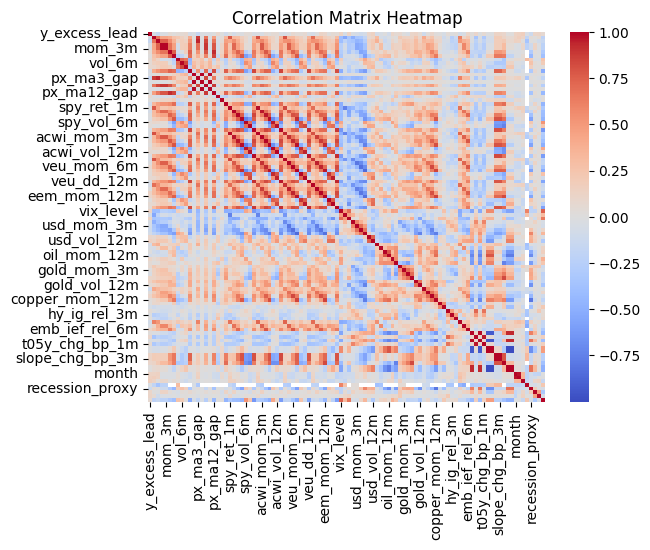

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
# Render the heatmap
plt.figure()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [37]:
list(dataset.columns)

['date',
 'asset_id',
 'y_excess_lead',
 'ret_1m',
 'ret_2m',
 'ret_3m',
 'mom_3m',
 'mom_6m',
 'mom_12m',
 'vol_3m',
 'vol_6m',
 'vol_12m',
 'dd_12m',
 'ma_3m',
 'px_ma3_gap',
 'ma_6m',
 'px_ma6_gap',
 'ma_12m',
 'px_ma12_gap',
 'skew_6m',
 'kurt_6m',
 'rsi_9m',
 'spy_ret_1m',
 'spy_mom_3m',
 'spy_mom_6m',
 'spy_mom_12m',
 'spy_vol_6m',
 'spy_vol_12m',
 'spy_dd_12m',
 'acwi_ret_1m',
 'acwi_mom_3m',
 'acwi_mom_6m',
 'acwi_mom_12m',
 'acwi_vol_6m',
 'acwi_vol_12m',
 'acwi_dd_12m',
 'veu_ret_1m',
 'veu_mom_3m',
 'veu_mom_6m',
 'veu_mom_12m',
 'veu_vol_6m',
 'veu_vol_12m',
 'veu_dd_12m',
 'eem_ret_1m',
 'eem_mom_3m',
 'eem_mom_6m',
 'eem_mom_12m',
 'eem_vol_6m',
 'eem_vol_12m',
 'eem_dd_12m',
 'vix_level',
 'vix_chg_1m',
 'vix_z_24m',
 'usd_ret_1m',
 'usd_mom_3m',
 'usd_mom_6m',
 'usd_mom_12m',
 'usd_vol_6m',
 'usd_vol_12m',
 'oil_ret_1m',
 'oil_mom_3m',
 'oil_mom_6m',
 'oil_mom_12m',
 'oil_vol_6m',
 'oil_vol_12m',
 'gold_ret_1m',
 'gold_mom_3m',
 'gold_mom_6m',
 'gold_mom_12m',
 'gold_vo

In [48]:
# Need to drop redundant columns, like all that have basis points instead of decimals. 


# Assuming `df` is your dataset
columns_to_drop = [
    't10y_chg_bp_1w', 't05y_chg_bp_1w', 'slope_10y_3m_bp', 'slope_chg_bp_4w', "slope_chg_bp_3m",
    'curve_proxy_bp',  'slope_10y_3m_bp', 't05y_chg_bp_1m', 't10y_chg_bp_1m',# Add any other basis points columns here
]

dataset = dataset.drop(columns=columns_to_drop, errors='ignore')



Next steps:
- start building an xgboost and do a time aware train/test split
- evaluate performance on the test set
- tune hyperparameters

In [49]:
dataset.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 101 columns):
 #    Column                    Non-Null Count  Dtype         
---   ------                    --------------  -----         
 0    date                      737 non-null    datetime64[ns]
 1    asset_id                  737 non-null    object        
 2    y_excess_lead             737 non-null    float64       
 3    ret_1m                    726 non-null    float64       
 4    ret_2m                    715 non-null    float64       
 5    ret_3m                    704 non-null    float64       
 6    mom_3m                    704 non-null    float64       
 7    mom_6m                    671 non-null    float64       
 8    mom_12m                   605 non-null    float64       
 9    vol_3m                    704 non-null    float64       
 10   vol_6m                    671 non-null    float64       
 11   vol_12m                   605 non-null    float64       
 12   dd_12m

In [50]:
dataset.describe()

,date,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,...,slope_z_24m,curve_proxy,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season_quarters,vix_high
count,737,7.37e+02,7.26e+02,7.15e+02,7.04e+02,7.04e+02,6.71e+02,6.05e+02,7.04e+02,6.71e+02,...,4.84e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02,7.37e+02
mean,2022-10-30 04:39:24.179104768,0.00413,0.00606,0.013,0.0214,0.0214,0.0421,0.081,0.0411,0.0425,...,-0.794,0.0241,6.24,2.42,4.9,0.0448,0.746,0.104,0.343,0.478
min,2020-01-31 00:00:00,-0.208,-0.207,-0.259,-0.224,-0.224,-0.3,-0.318,0.00133,0.00563,...,-3.63,-0.000684,1.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0
25%,2021-05-31 00:00:00,-0.0239,-0.0221,-0.0219,-0.0257,-0.0257,-0.0281,-0.0402,0.0175,0.0245,...,-1.96,0.00087,3.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0
50%,2022-10-31 00:00:00,0.0053,0.00695,0.0123,0.0176,0.0176,0.0348,0.0677,0.0337,0.0393,...,-0.899,0.0353,6.0,2.0,5.0,0.0,1.0,0.0,0.0,0.0
75%,2024-03-29 00:00:00,0.0319,0.0342,0.0484,0.0646,0.0646,0.107,0.172,0.0584,0.0575,...,0.624,0.0456,9.0,3.0,5.0,0.0,1.0,0.0,1.0,1.0
max,2025-07-31 00:00:00,0.164,0.164,0.291,0.329,0.329,0.433,0.836,0.188,0.126,...,2.39,0.0486,12.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0
std,NaN,0.0501,0.0505,0.0702,0.0797,0.0797,0.113,0.185,0.0308,0.0234,...,1.72,0.0206,3.42,1.11,0.306,0.207,0.435,0.306,0.475,0.5


In [56]:
# get complete data so far. Need to backfill other data. 
# need to set it too tail of 484 for the slope and then remove the standardized yield curve. 

df = dataset.tail(n=605).reset_index(drop=True)
df = df.drop(columns=['vix_z_24m', "slope_z_24m"], errors='ignore')
df

,date,asset_id,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,2021-01-29,AVEM,0.03,0.0263,0.105,0.231,0.231,0.254,0.255,0.0436,...,1,1,5,0,0,0,True,1,1,high
1,2021-01-29,BYLD,-0.0151,-0.0089,-0.00443,0.0106,0.0106,0.00178,0.0191,0.012,...,1,1,5,0,0,0,True,1,1,high
2,2021-01-29,ESGD,0.0232,-0.00958,0.0408,0.193,0.193,0.178,0.102,0.0786,...,1,1,5,0,0,0,True,1,1,high
3,2021-01-29,HYEM,0.013,-0.00879,0.0228,0.0631,0.0631,0.0615,0.0443,0.0259,...,1,1,5,0,0,0,True,1,1,high
4,2021-01-29,IEF,-0.0237,-0.0109,-0.0133,-0.00994,-0.00994,-0.0299,0.0516,0.0072,...,1,1,5,0,0,0,True,1,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,2025-07-31,SNPE,0.0227,0.0253,0.0847,0.145,0.145,0.0539,0.134,0.0183,...,7,3,5,0,1,1,True,1,0,low
601,2025-07-31,VBK,0.0311,0.0197,0.072,0.141,0.141,-0.0293,0.0863,0.0228,...,7,3,5,0,1,1,True,1,0,low
602,2025-07-31,VNQ,0.0314,0.000898,0.00779,0.0191,0.0191,0.00431,0.0242,0.00518,...,7,3,5,0,1,1,True,1,0,low
603,2025-07-31,VNQI,0.0556,-0.0202,0.0238,0.0541,0.0541,0.127,0.117,0.034,...,7,3,5,0,1,1,True,1,0,low


In [57]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score

# Drop non-feature cols
drop_cols = ["date", "y_excess_lead"]
# Example train-test split by date
train = df[df["date"] < "2025-07-23"]
test  = df[df["date"] >= "2025-07-23"]

X_train, y_train = train.drop(columns=drop_cols), train["y_excess_lead"]
X_test, y_test   = test.drop(columns=drop_cols), test["y_excess_lead"]

cat_features = ["asset_id", "asset_class", "region", "vix_regime"]
# Handle categoricals (requires latest xgboost)
for col in cat_features:
    X_train[col] = X_train[col].astype("category")
    X_test[col]  = X_test[col].astype("category")
    



In [59]:
y_test

594    0.0395
595   0.00811
596    0.0584
597    0.0138
598   0.00981
599    0.0524
600    0.0227
601    0.0311
602    0.0314
603    0.0556
604   0.00656
Name: y_excess_lead, dtype: float64

In [53]:
X_train

,asset_id,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,vol_12m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,AVEM,0.0284,-0.000551,0.000534,0.000534,-0.072,0.0516,0.0283,0.0321,0.0283,...,12,4,5,0,0,0,False,0,0,medium
1,BYLD,0.00433,0.00265,0.000841,0.000841,9.39e-05,-0.0125,0.00351,0.00563,0.00789,...,12,4,5,0,0,0,False,0,0,medium
2,ESGD,0.0463,-0.00437,0.0283,0.0283,0.0198,0.118,0.0512,0.0369,0.0294,...,12,4,5,0,0,0,False,0,0,medium
3,HYEM,0.0172,-0.00499,-0.0161,-0.0161,-0.0327,-0.013,0.0202,0.0157,0.0132,...,12,4,5,0,0,0,False,0,0,medium
4,IEF,-0.00524,0.00562,0.00117,0.00117,0.000824,-0.0333,0.00911,0.0129,0.0142,...,12,4,5,0,0,0,False,0,0,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,SNPE,0.0579,0.117,0.0999,0.0999,0.0438,0.118,0.0418,0.0443,0.0362,...,6,2,5,0,1,0,False,0,0,low
469,VBK,0.0513,0.119,0.102,0.102,-0.0081,0.113,0.0425,0.0612,0.0618,...,6,2,5,0,1,0,False,0,0,low
470,VNQ,0.00688,0.0182,-0.00668,-0.00668,0.02,0.104,0.0194,0.0245,0.0448,...,6,2,5,0,1,0,False,0,0,low
471,VNQI,0.0448,0.0758,0.141,0.141,0.167,0.197,0.0154,0.0229,0.04,...,6,2,5,0,1,0,False,0,0,low


In [63]:

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=12,
    subsample=0.7,
    colsample_bytree=0.7,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    objective = "reg:quantileerror",
    quantile_alpha = 0.5
)

model.fit(X_train, y_train)
preds = model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, preds))
print("R^2:", r2_score(y_test, preds))


RMSE: 0.03174361338052316
R^2: -1.911588101857852


In [61]:
preds

array([ 0.01227941,  0.0019581 ,  0.00644955,  0.00319083, -0.00085573,
        0.01135566,  0.01664778,  0.01917378,  0.01028525,  0.00590734,
        0.02273016], dtype=float32)

Need to make time aware split blocks because we have multiple values per asset per date.

In [ ]:
# ============================================
# Monthly y_excess_lead forecasting with XGBoost
# - Unique-date holdout (last H months)
# - Expanding date-block CV (no same-date leakage)
# - Early stopping inside folds
# - Parallel folds (no thread thrash inside model)
# - Safer hyperparam space to avoid flat predictions
# ============================================

import numpy as np, pandas as pd, warnings, optuna, xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from joblib import Parallel, delayed
from scipy.stats import spearmanr

# -------------------------
# 0) Helpers / config
# -------------------------
def rmse(a, b): 
    return root_mean_squared_error(a, b)

def make_date_block_splits(
    dates: pd.Series,
    n_splits: int = 8,
    val_periods: int = 2,    # months per validation fold
    gap: int = 0,            # embargo in months
    min_train_periods: int = 18
):
    """Expanding-window folds by unique dates (keeps all ETFs of a date together)."""
    if not np.issubdtype(dates.dtype, np.datetime64):
        dates = pd.to_datetime(dates)
    uniq = np.array(sorted(dates.unique()))
    n = len(uniq)
    if n < (min_train_periods + gap + val_periods + 1):
        raise ValueError("Not enough periods for requested CV config.")

    split_idxs = np.linspace(
        min_train_periods - 1,
        n - (gap + val_periods) - 1,
        num=n_splits,
        dtype=int
    )

    folds = []
    for train_end_idx in split_idxs:
        train_dates = uniq[: train_end_idx + 1]
        val_start = train_end_idx + 1 + gap
        val_end   = val_start + val_periods
        if val_end > n:
            break
        val_dates = uniq[val_start:val_end]
        tr_idx = np.where(dates.isin(train_dates).values)[0]
        va_idx = np.where(dates.isin(val_dates).values)[0]
        if len(tr_idx) and len(va_idx):
            folds.append((tr_idx, va_idx))
    if not folds:
        raise ValueError("No valid folds. Relax parameters.")
    return folds

# -------------------------
# 1) Data prep (monthly)
# -------------------------
DF = df.copy().sort_values(["date","asset_id"]).reset_index(drop=True)  # <-- your monthly panel
TARGET = "y_excess_lead"
DROP_COLS = ["date", TARGET]

# Clip tails (optional; helps stability on monthly horizons)
DF[TARGET] = DF[TARGET].clip(-0.30, 0.30)

# Categoricals (set BEFORE split so categories are unified)
cat_cols = [c for c in ["asset_id","asset_class","region","vix_regime"] if c in DF.columns]
for c in cat_cols:
    DF[c] = DF[c].astype("category")

X = DF.drop(columns=[c for c in DROP_COLS if c in DF.columns])
y = DF[TARGET].values
dates = pd.to_datetime(DF["date"])

# -------------------------
# 2) True holdout (last H unique months)
# -------------------------
HOLDOUT_MONTHS = 6
uniq_dates = np.array(sorted(dates.unique()))
hold_dates = set(uniq_dates[-HOLDOUT_MONTHS:])
mask_hold  = dates.isin(hold_dates).values
mask_tune  = ~mask_hold

X_tune, y_tune, dates_tune = X.iloc[mask_tune].copy(), y[mask_tune].copy(), dates[mask_tune].copy()
X_hold, y_hold             = X.iloc[mask_hold].copy(),  y[mask_hold].copy()

# -------------------------
# 3) Optional feature cleaning (on tuning window)
#    - Drop high-NaN or constant columns
# -------------------------
nan_thresh = 0.40
bad_nan   = set(X_tune.columns[X_tune.isna().mean() > nan_thresh])
bad_const = set([c for c in X_tune.columns if X_tune[c].nunique(dropna=True) <= 1])
drop_cols = sorted(bad_nan.union(bad_const))
if drop_cols:
    print(f"Dropping {len(drop_cols)} pathological cols:", drop_cols[:15], "...")
    X_tune.drop(columns=drop_cols, inplace=True)
    X_hold.drop(columns=[c for c in drop_cols if c in X_hold.columns], inplace=True)

# -------------------------
# 4) CV folds on tuning window ONLY (by date blocks)
# -------------------------
N_SPLITS, VAL_PERIODS, GAP, MIN_TRAIN = 8, 2, 0, 34
folds = make_date_block_splits(
    dates=dates_tune,
    n_splits=N_SPLITS,
    val_periods=VAL_PERIODS,
    gap=GAP,
    min_train_periods=MIN_TRAIN
)

# -------------------------
# 5) Fold worker (early stopping inside)
# -------------------------
def _fit_predict_fold(tr_idx, va_idx, params):
    X_tr, y_tr = X_tune.iloc[tr_idx], y_tune[tr_idx]
    X_va, y_va = X_tune.iloc[va_idx], y_tune[va_idx]

    p = dict(params)
    p.update({
        "n_jobs": -1,               # folds parallel externally
        "eval_metric": "rmse",     # still fine to log, but no ES
    })
    model = xgb.XGBRegressor(**p)
    model.fit(X_tr, y_tr, verbose=False)
    return va_idx, model.predict(X_va)

CV_N_JOBS = 4  # parallelize folds; keep trials serial to avoid oversubscription

# -------------------------
# 6) Optuna objective (weighted mean of per-fold RMSE)
# -------------------------
def objective(trial: optuna.Trial) -> float:
    params = {
        # learning dynamics
        "n_estimators": trial.suggest_int("n_estimators", 500, 501, step=1),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05, log=True),

        # capacity / regularization — constrained to avoid "no-split" stumps
        "max_depth": trial.suggest_int("max_depth", 4, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 4.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "subsample": trial.suggest_float("subsample", 0.8, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.8, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 5, log=True),

        # system
        "tree_method": "hist",
        "enable_categorical": True,
        "random_state": 42,
    }

    # run folds in parallel; use weighted mean of per-fold RMSE
    results = Parallel(n_jobs=4)(
        delayed(_fit_predict_fold)(tr, va, params) for (tr, va) in folds
    )
    rmses, r2s, sizes = [], [], []
    for va_idx, preds in results:
        rmses.append(root_mean_squared_error(y_tune[va_idx], preds))
        r2_fold = r2_score(y_tune[va_idx], preds)
        r2s.append(r2_fold)
        sizes.append(len(va_idx))

    # Weighted averages of RMSE and R^2
    avg_rmse = float(np.average(rmses, weights=sizes))
    avg_r2 = float(np.average(r2s, weights=sizes))
    
    return avg_rmse, -avg_r2 

# -------------------------
# 7) Run study (trials serial)
# -------------------------
study = optuna.create_study(
    directions=["minimize", "minimize"],  # Minimize RMSE and maximize r2 rank
    sampler=optuna.samplers.TPESampler(seed=42)
)   
# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=150, n_jobs=1, show_progress_bar=True)

# print("Best CV RMSE:", study.best_value)
# Print the Pareto front
print("Pareto front:")
for trial in study.best_trials:
    print(f"RMSE: {trial.values[0]:.6f}, R2: {-trial.values[1]:.6f}")  # Negate r2 for readability
print("Best params:", study.best_params)

# -------------------------
# 8) Final model
#    - Use last CV fold as recent validation for ES
#    - Train only on tuning window (holdout untouched)
# -------------------------

# final fit on ALL X_tune (no ES)
best = study.best_params
best.update({
    "tree_method": "hist", "enable_categorical": True, "random_state": 42, "n_jobs": -1, "eval_metric": "rmse"
})
final_model = xgb.XGBRegressor(**best)
final_model.fit(X_tune, y_tune, verbose=False)

y_pred_hold = final_model.predict(X_hold)
print("Pred std (holdout):", float(np.std(y_pred_hold)))

hold_rmse = rmse(y_hold, y_pred_hold)
hold_mae  = mean_absolute_error(y_hold, y_pred_hold)
hold_r2   = r2_score(y_hold, y_pred_hold)
hold_spr  = spearmanr(y_hold, y_pred_hold, nan_policy="omit").correlation

print(f"Holdout RMSE : {hold_rmse:.6f}")
print(f"Holdout MAE  : {hold_mae:.6f}")
print(f"Holdout R^2  : {hold_r2:.4f}")
print(f"Holdout Spearman (rank): {hold_spr:.4f}")

[I 2025-08-25 05:50:14,701] A new study created in memory with name: no-name-d400f27a-36c9-414e-9482-e414fccf7f25


Dropping 1 pathological cols: ['recession_flag'] ...


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2025-08-25 05:50:15,971] Trial 0 finished with values: [0.03918940763528945, 0.3109013797146604] and parameters: {'n_estimators': 500, 'learning_rate': 0.046187109390049115, 'max_depth': 6, 'min_child_weight': 2.79597545259111, 'gamma': 0.07800932022121826, 'subsample': 0.8311989040672406, 'colsample_bytree': 0.8116167224336399, 'reg_alpha': 0.4330880728874676, 'reg_lambda': 0.16730402817820234}.
[I 2025-08-25 05:50:16,353] Trial 1 finished with values: [0.039016105151262255, 0.29829798760115145] and parameters: {'n_estimators': 501, 'learning_rate': 0.010336843570697403, 'max_depth': 7, 'min_child_weight': 3.497327922401265, 'gamma': 0.10616955533913808, 'subsample': 0.8363649934414201, 'colsample_bytree': 0.8366809019706868, 'reg_alpha': 0.15212112147976886, 'reg_lambda': 0.08730885649333642}.
[I 2025-08-25 05:50:16,724] Trial 2 finished with values: [0.038331729931438234, 0.23334800882252116] and parameters: {'n_estimators': 500, 'learning_rate': 0.01597939871741036, 'max_depth':

RuntimeError: A single best trial cannot be retrieved from a multi-objective study. Consider using Study.best_trials to retrieve a list containing the best trials.

In [ ]:
#I left it looking at reducing the min child weight and 

In [176]:
y_hold, y_pred_hold

(array([ 1.18164433e-02, -8.21833629e-03, -6.72424894e-04, -1.11352771e-02,
        -7.85092607e-05,  1.00387282e-02, -5.91771372e-02, -8.10466122e-02,
        -2.92737890e-02, -2.59893516e-05, -6.97250274e-02,  1.97336758e-03,
        -3.44345108e-03,  3.28112437e-02, -1.21775731e-02,  6.86586680e-03,
         4.98568358e-02, -1.90670577e-02, -1.87341813e-02, -2.79764778e-02,
         5.64293869e-02,  1.00938969e-02,  5.88800633e-02,  9.83366182e-04,
         4.24333528e-02,  1.34443697e-02, -1.60381502e-02,  5.91956463e-02,
         5.20975787e-02,  6.00381504e-02,  7.47878302e-03,  2.58066104e-02,
         7.38021157e-02,  7.36098705e-02,  1.33936242e-02,  2.21779640e-02,
         1.44548123e-02,  1.24525405e-02,  4.48261635e-02,  5.41833601e-02,
         4.76467480e-02,  3.35001523e-03,  4.11588634e-02,  3.38003150e-02,
         5.29819625e-03, -1.73766132e-03, -2.55181567e-02,  5.28544341e-03,
        -9.77425977e-03, -7.55792318e-03,  2.13607975e-02,  1.57454586e-02,
        -2.9

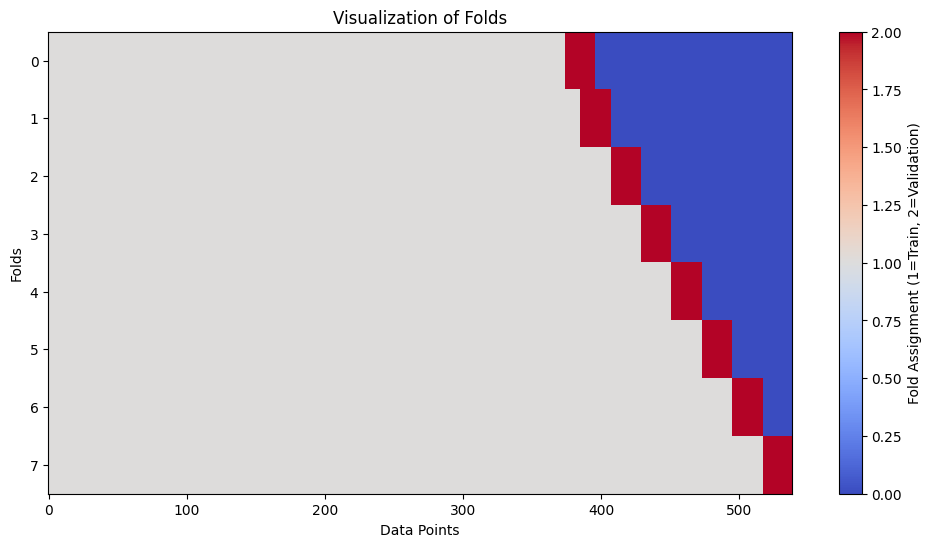

In [174]:
folds = make_date_block_splits(
    dates=dates_tune,
    n_splits=8,
    val_periods=2,
    gap=0,
    min_train_periods=34
)

# Determine the total number of data points
n_samples = max(max(train.max(), val.max()) for train, val in folds) + 1

# Create a matrix to represent the folds
fold_matrix = np.zeros((len(folds), n_samples))

for i, (train_idx, val_idx) in enumerate(folds):
    fold_matrix[i, train_idx] = 1  # Mark training samples
    fold_matrix[i, val_idx] = 2  # Mark validation samples

# Plot the fold matrix
plt.figure(figsize=(12, 6))
plt.imshow(fold_matrix, aspect='auto', cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Fold Assignment (1=Train, 2=Validation)')
plt.xlabel('Data Points')
plt.ylabel('Folds')
plt.title('Visualization of Folds')
plt.show()

In [140]:
folds[0]

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177

In [144]:
X.iloc[folds[0][1], :]

,asset_id,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,vol_12m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
220,AVEM,-0.109,-0.115,-0.117,-0.117,-0.217,-0.267,0.0606,0.0468,0.0384,...,9,3,5,0,1,0,False,0,1,high
221,BYLD,-0.0307,-0.0585,-0.0268,-0.0268,-0.0799,-0.129,0.0365,0.029,0.021,...,9,3,5,0,1,0,False,0,1,high
222,ESGD,-0.0954,-0.152,-0.106,-0.106,-0.223,-0.259,0.0791,0.0606,0.0518,...,9,3,5,0,1,0,False,0,1,high
223,HYEM,-0.0435,-0.0408,-0.0349,-0.0349,-0.135,-0.228,0.0277,0.0265,0.0247,...,9,3,5,0,1,0,False,0,1,high
224,IEF,-0.0473,-0.0841,-0.0569,-0.0569,-0.0991,-0.156,0.0421,0.031,0.0243,...,9,3,5,0,1,0,False,0,1,high
225,ISCF,-0.108,-0.153,-0.0916,-0.0916,-0.226,-0.25,0.092,0.0712,0.0586,...,9,3,5,0,1,0,False,0,1,high
226,SNPE,-0.0956,-0.135,-0.0572,-0.0572,-0.21,-0.143,0.0957,0.0726,0.0647,...,9,3,5,0,1,0,False,0,1,high
227,VBK,-0.09,-0.112,-0.0077,-0.0077,-0.211,-0.3,0.106,0.0825,0.0718,...,9,3,5,0,1,0,False,0,1,high
228,VNQ,-0.129,-0.181,-0.111,-0.111,-0.247,-0.187,0.11,0.0712,0.0749,...,9,3,5,0,1,0,False,0,1,high
229,VNQI,-0.12,-0.169,-0.138,-0.138,-0.265,-0.285,0.079,0.0537,0.047,...,9,3,5,0,1,0,False,0,1,high


In [118]:
X_tune

,asset_id,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,vol_6m,vol_12m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,AVEM,0.0263,0.105,0.231,0.231,0.254,0.255,0.0436,0.0473,0.0819,...,1,1,5,0,0,0,True,1,1,high
1,BYLD,-0.0089,-0.00443,0.0106,0.0106,0.00178,0.0191,0.012,0.00846,0.0197,...,1,1,5,0,0,0,True,1,1,high
2,ESGD,-0.00958,0.0408,0.193,0.193,0.178,0.102,0.0786,0.068,0.0741,...,1,1,5,0,0,0,True,1,1,high
3,HYEM,-0.00879,0.0228,0.0631,0.0631,0.0615,0.0443,0.0259,0.0222,0.0563,...,1,1,5,0,0,0,True,1,1,high
4,IEF,-0.0109,-0.0133,-0.00994,-0.00994,-0.0299,0.0516,0.0072,0.00749,0.0153,...,1,1,5,0,0,0,True,1,1,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,SNPE,0.0589,0.047,0.0664,0.0664,0.14,0.33,0.0352,0.0234,0.0276,...,11,4,5,0,1,0,False,0,0,low
513,VBK,0.131,0.128,0.155,0.155,0.209,0.39,0.0702,0.0511,0.0571,...,11,4,5,0,1,0,False,0,0,low
514,VNQ,0.0426,0.0076,0.0405,0.0405,0.204,0.252,0.0414,0.0381,0.0515,...,11,4,5,0,1,0,False,0,0,low
515,VNQI,-0.00573,-0.0746,-0.0262,-0.0262,0.041,0.102,0.0608,0.0502,0.0477,...,11,4,5,0,1,0,False,0,0,low


In [96]:
# Use a recent slice from the tuning set for ES; do NOT touch the true holdout
last_tr_idx, last_va_idx = folds[-1]
X_tr_full, y_tr_full = X.iloc[last_tr_idx], y[last_tr_idx]
X_va_last, y_va_last = X.iloc[last_va_idx], y[last_va_idx]

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    X_tr_full, y_tr_full,
    eval_set=[(X_va_last, y_va_last)],
    verbose=False,
)

# =========================
# 6) Holdout evaluation
# =========================
y_pred_hold = final_model.predict(X_hold)
hold_rmse = rmse(y_hold, y_pred_hold)
hold_mae  = mean_absolute_error(y_hold, y_pred_hold)
hold_r2   = r2_score(y_hold, y_pred_hold)
hold_spr  = spearmanr(y_hold, y_pred_hold, nan_policy="omit").correlation

print(f"Holdout RMSE : {hold_rmse:.6f}")
print(f"Holdout MAE  : {hold_mae:.6f}")
print(f"Holdout R^2  : {hold_r2:.4f}")
print(f"Holdout Spearman (rank): {hold_spr:.4f}")

Holdout RMSE : 0.031326
Holdout MAE  : 0.025721
Holdout R^2  : -2.0689
Holdout Spearman (rank): nan


Best I've seen in awhile

Best CV RMSE: 0.024382080912685407
Best params: {'n_estimators': 600, 'learning_rate': 0.05150372053007686, 'max_depth': 3, 'min_child_weight': 5.599047026613264, 'gamma': 9.310940383935304e-05, 'subsample': 0.7728794309912088, 'colsample_bytree': 0.7197518223219879, 'reg_alpha': 0.028832077632342055, 'reg_lambda': 2.7372210444211267}
Holdout RMSE : 0.017443
Holdout MAE  : 0.013515
Holdout R^2  : 0.0485
Holdout Spearman (rank): 0.0476

quantile 0.05: didn't seem much better......

In [80]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = [c for c in X.columns if c not in cat_cols]
pre = ColumnTransformer([
    ("num", StandardScaler(with_mean=True, with_std=True), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
], remainder="drop")

def en_objective(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    l1    = trial.suggest_float("l1_ratio", 0.0, 1.0)
    model = Pipeline([("pre", pre), ("est", ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=20000, random_state=42))])

    oof = np.full(X_tune.shape[0], np.nan)
    for tr_idx, va_idx in tscv.split(X_tune):
        model.fit(X_tune.iloc[tr_idx], y_tune[tr_idx])
        oof[va_idx] = model.predict(X_tune.iloc[va_idx])
    return rmse(y_tune[~np.isnan(oof)], oof[~np.isnan(oof)])

en_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
en_study.optimize(en_objective, n_trials=100, show_progress_bar=True)
print("ElasticNet best RMSE:", en_study.best_value, en_study.best_params)

[I 2025-08-24 07:27:20,728] A new study created in memory with name: no-name-904830de-773d-4f51-9c5a-f84148016710


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-08-24 07:27:20,776] Trial 0 finished with value: 0.03564560369869233 and parameters: {'alpha': 0.003148911647956862, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.03564560369869233.
[I 2025-08-24 07:27:20,806] Trial 1 finished with value: 0.03317758465406209 and parameters: {'alpha': 0.08471801418819976, 'l1_ratio': 0.5986584841970366}. Best is trial 1 with value: 0.03317758465406209.
[I 2025-08-24 07:27:22,467] Trial 2 finished with value: 0.056559101846492016 and parameters: {'alpha': 0.00042079886696066364, 'l1_ratio': 0.15599452033620265}. Best is trial 1 with value: 0.03317758465406209.
[I 2025-08-24 07:27:23,601] Trial 3 finished with value: 0.05577107412685068 and parameters: {'alpha': 0.0001707396743152812, 'l1_ratio': 0.8661761457749352}. Best is trial 1 with value: 0.03317758465406209.
[I 2025-08-24 07:27:23,628] Trial 4 finished with value: 0.03317758465406209 and parameters: {'alpha': 0.025378155082656634, 'l1_ratio': 0.7080725777960455}. Best is tr

In [81]:
# ========= Final fit on all tuning data =========
best_alpha = en_study.best_params["alpha"]
best_l1    = en_study.best_params["l1_ratio"]

final_en = Pipeline([
    ("pre", pre),
    ("est", ElasticNet(alpha=best_alpha, l1_ratio=best_l1,
                       max_iter=20000, random_state=42))
])
final_en.fit(X_tune, y_tune)

# ========= Holdout evaluation =========
y_pred_hold = final_en.predict(X_hold)

hold_rmse = rmse(y_hold, y_pred_hold)
hold_mae  = mean_absolute_error(y_hold, y_pred_hold)
hold_r2   = r2_score(y_hold, y_pred_hold)
hold_spr  = spearmanr(y_hold, y_pred_hold, nan_policy="omit").correlation

print(f"ElasticNet Holdout RMSE : {hold_rmse:.6f}")
print(f"ElasticNet Holdout MAE  : {hold_mae:.6f}")
print(f"ElasticNet Holdout R^2  : {hold_r2:.4f}")
print(f"ElasticNet Holdout Spearman: {hold_spr:.4f}")

ElasticNet Holdout RMSE : 0.032003
ElasticNet Holdout MAE  : 0.026697
ElasticNet Holdout R^2  : -2.2030
ElasticNet Holdout Spearman: 0.2857


In [85]:

from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr


def rmse(a, b): 
    return root_mean_squared_error(a, b)

# ====== Assume DF, X, y, cat_cols, X_tune/y_tune/X_hold/y_hold already defined as in your XGB setup ======
# If not, reuse the exact prep you used for XGB (monthly; last 8 months as holdout).


# Identify numeric vs categorical for preprocessing
num_cols = [c for c in X.columns if c not in (cat_cols or [])]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=True, with_std=True), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

# Monthly CV: 5 folds, 8-month validation, 1-month embargo (same as your XGB loop)
tscv = TimeSeriesSplit(n_splits=5, test_size=8, gap=1)

# -------- parallel fold worker --------
def _fit_predict_fold(tr_idx, va_idx, params):
    X_tr, y_tr = X_tune.iloc[tr_idx], y_tune[tr_idx]
    X_va, y_va = X_tune.iloc[va_idx], y_tune[va_idx]

    model = Pipeline(steps=[
        ("pre", preprocess),
        ("svr", SVR(**params))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        model.fit(X_tr, y_tr)

    preds = model.predict(X_va)
    return va_idx, preds

CV_N_JOBS = 4  # folds in parallel; keep trials serial

# -------- Optuna objective --------
def objective(trial: optuna.Trial) -> float:
    params = {
        "kernel": "rbf",  # start with RBF; it’s the usual winner
        "C": trial.suggest_float("C", 1e-1, 1e3, log=True),
        "epsilon": trial.suggest_float("epsilon", 1e-3, 5e-2, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 1e0, log=True),
        "shrinking": True,
        "tol": 1e-3,
        "cache_size": 500,  # MB
    }

    oof = np.full(X_tune.shape[0], np.nan, dtype=float)
    results = Parallel(n_jobs=CV_N_JOBS, prefer="threads")(
        delayed(_fit_predict_fold)(tr_idx, va_idx, params)
        for (tr_idx, va_idx) in tscv.split(X_tune)
    )
    for va_idx, preds in results:
        oof[va_idx] = preds

    return rmse(y_tune[~np.isnan(oof)], oof[~np.isnan(oof)])

# ---- Run tuning (trials serial; folds parallel) ----
study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=150, n_jobs=1, show_progress_bar=True)

print("SVR Best CV RMSE:", study.best_value)
print("SVR Best params:", study.best_params)

# ===== Final training on ALL tuning data =====
best_params = study.best_params.copy()
final_svr = Pipeline(steps=[
    ("pre", preprocess),
    ("svr", SVR(**best_params))
])
final_svr.fit(X_tune, y_tune)

# ===== Holdout evaluation (same metrics as your XGB) =====
y_pred_hold = final_svr.predict(X_hold)

hold_rmse = rmse(y_hold, y_pred_hold)
hold_mae  = mean_absolute_error(y_hold, y_pred_hold)
hold_r2   = r2_score(y_hold, y_pred_hold)
hold_spr  = spearmanr(y_hold, y_pred_hold, nan_policy="omit").correlation

print(f"SVR Holdout RMSE : {hold_rmse:.6f}")
print(f"SVR Holdout MAE  : {hold_mae:.6f}")
print(f"SVR Holdout R^2  : {hold_r2:.4f}")
print(f"SVR Holdout Spearman (rank): {hold_spr:.4f}")


[I 2025-08-24 07:36:12,404] A new study created in memory with name: no-name-c4e3776e-ee93-4499-8bad-6ecec6d72aee


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2025-08-24 07:36:12,459] Trial 0 finished with value: 0.03201191926295811 and parameters: {'C': 3.14891164795686, 'epsilon': 0.04123206532618727, 'gamma': 0.08471801418819976}. Best is trial 0 with value: 0.03201191926295811.
[I 2025-08-24 07:36:12,548] Trial 1 finished with value: 0.04181399613930619 and parameters: {'C': 24.81040974867809, 'epsilon': 0.0018410729205738682, 'gamma': 0.0004207053950287938}. Best is trial 0 with value: 0.03201191926295811.
[I 2025-08-24 07:36:12,589] Trial 2 finished with value: 0.02878623938926206 and parameters: {'C': 0.1707396743152812, 'epsilon': 0.029621516588303493, 'gamma': 0.025378155082656634}. Best is trial 2 with value: 0.02878623938926206.
[I 2025-08-24 07:36:12,642] Trial 3 finished with value: 0.0332029629400728 and parameters: {'C': 67.9657809075815, 'epsilon': 0.0010838581269344747, 'gamma': 0.7579479953347994}. Best is trial 2 with value: 0.02878623938926206.
[I 2025-08-24 07:36:13,029] Trial 4 finished with value: 0.0360981220820794

In [67]:
test_pred = final_model.predict(X_test)
pd.DataFrame(test_pred)

,0
0,0.0329
1,0.0228
2,0.0247
3,0.0199
4,0.0205
5,0.0301
6,0.0293
7,0.0311
8,0.0268
9,0.0326


In [69]:
best_params

{'n_estimators': 600,
 'learning_rate': 0.05150372053007686,
 'max_depth': 3,
 'min_child_weight': 5.599047026613264,
 'gamma': 9.310940383935304e-05,
 'subsample': 0.7728794309912088,
 'colsample_bytree': 0.7197518223219879,
 'reg_alpha': 0.028832077632342055,
 'reg_lambda': 2.7372210444211267,
 'tree_method': 'hist',
 'enable_categorical': True,
 'random_state': 42,
 'n_jobs': -1,
 'eval_metric': 'rmse',
 'early_stopping_rounds': 50}

In [70]:
import pandas as pd

# Assuming `model.feature_names_in_` and `model.feature_importances_` are numpy arrays
# Replace `model` with the name of your trained model object
features = final_model.feature_names_in_
importances = final_model.feature_importances_

# Create the DataFrame
feature_importance_df = pd.DataFrame({
    'features': features,
    'importances': importances
})

# Sort by importances in descending order
feature_importance_df = feature_importance_df.sort_values(by='importances', ascending=False)

# Display the sorted DataFrame
feature_importance_df.head(15)

,features,importances
35,veu_mom_3m,0.0555
70,copper_mom_6m,0.0476
44,eem_mom_12m,0.0462
36,veu_mom_6m,0.0416
26,spy_dd_12m,0.0354
55,usd_vol_12m,0.0321
42,eem_mom_3m,0.0312
77,emb_ief_rel_1m,0.0274
28,acwi_mom_3m,0.0262
40,veu_dd_12m,0.0247


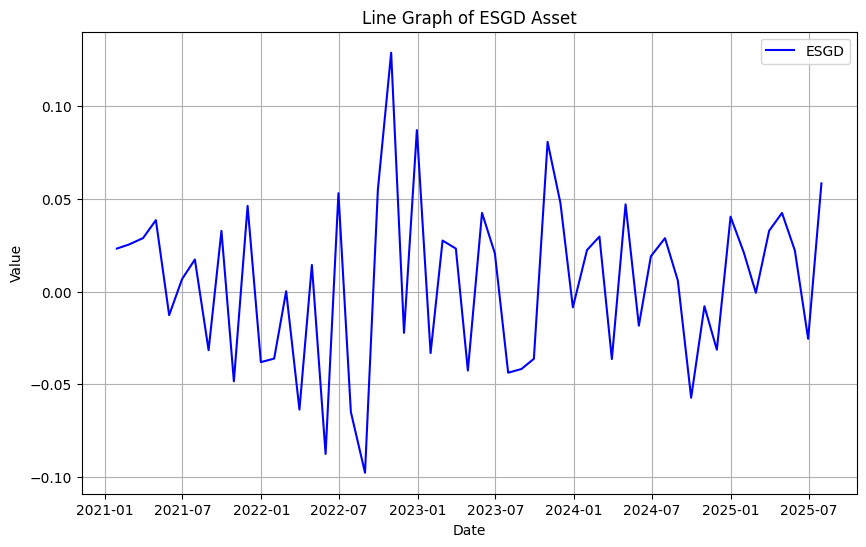

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named `df` and has columns 'datetime', 'asset', and the value column (e.g., 'value')

# Filter the DataFrame for the "ESGD" asset
esgd_data = df[df['asset_id'] == 'ESGD']

# Plot the line graph
plt.figure(figsize=(10, 6))
plt.plot(esgd_data['date'], esgd_data['y_excess_lead'], label='ESGD', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Line Graph of ESGD Asset')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

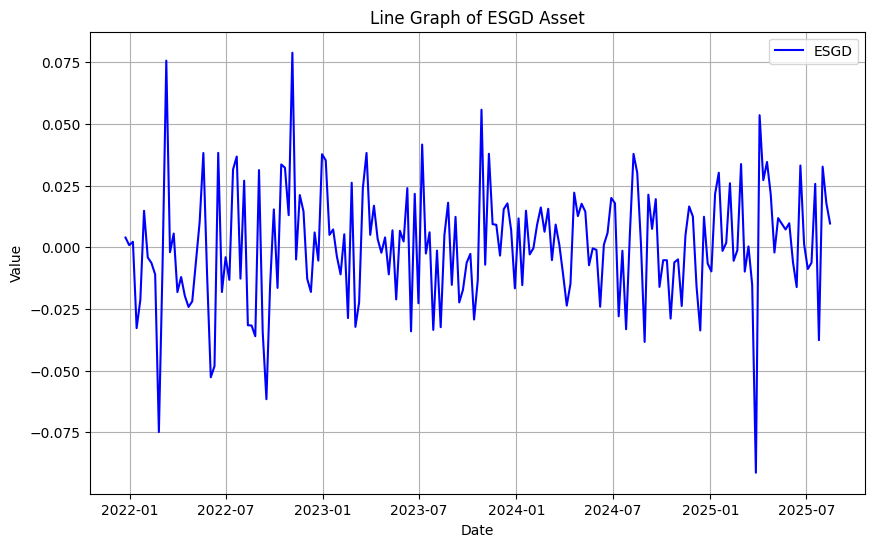

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named `df` and has columns 'datetime', 'asset', and the value column (e.g., 'value')

# Filter the DataFrame for the "ESGD" asset
esgd_data = df[df['asset_id'] == 'ESGD']

# Plot the line graph
plt.figure(figsize=(10, 6))
plt.plot(esgd_data['date'], esgd_data['y_excess_lead'], label='ESGD', color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Line Graph of ESGD Asset')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [72]:
esgd_data.reset_index(drop=True, inplace=True)
esgd_data

,date,asset_id,y_excess_lead,ret_1m,ret_2m,ret_3m,mom_3m,mom_6m,mom_12m,vol_3m,...,month,quarter,week_of_month,recession_flag,recession_proxy,fed_meeting_week,earnings_season,earnings_season_quarters,vix_high,vix_regime
0,2021-01-29,ESGD,0.0232,-0.00958,0.0408,0.193,0.193,0.178,0.102,0.0786,...,1,1,5,0,0,0,True,1,1,high
1,2021-02-26,ESGD,0.0254,0.0232,0.0134,0.0649,0.0649,0.149,0.214,0.0302,...,2,1,4,0,0,0,False,0,1,high
2,2021-03-31,ESGD,0.0288,0.0254,0.0492,0.0392,0.0392,0.206,0.454,0.0196,...,3,1,5,0,0,0,False,0,0,medium
3,2021-04-30,ESGD,0.0385,0.0289,0.055,0.0795,0.0795,0.288,0.416,0.00284,...,4,2,5,0,0,0,True,1,0,medium
4,2021-05-31,ESGD,-0.0127,0.0385,0.0685,0.0956,0.0956,0.167,0.396,0.00682,...,5,2,5,0,0,0,False,0,0,low
5,2021-06-30,ESGD,0.00667,-0.0127,0.0253,0.0549,0.0549,0.0962,0.333,0.0272,...,6,2,5,0,0,0,False,0,0,low
6,2021-07-30,ESGD,0.0173,0.00671,-0.0061,0.0322,0.0322,0.114,0.312,0.0259,...,7,3,5,0,0,0,True,1,0,medium
7,2021-08-31,ESGD,-0.0317,0.0173,0.0242,0.0111,0.0111,0.108,0.273,0.0152,...,8,3,5,0,0,0,False,0,0,low
8,2021-09-30,ESGD,0.0328,-0.0316,-0.0148,-0.00822,-0.00822,0.0462,0.262,0.0258,...,9,3,5,0,0,0,False,0,1,medium
9,2021-10-29,ESGD,-0.0485,0.0328,0.000124,0.0175,0.0175,0.0502,0.353,0.0336,...,10,4,5,0,0,0,True,1,0,low


In [73]:
from sklearn.model_selection import TimeSeriesSplit

ts_cv = TimeSeriesSplit(
    n_splits=5,
    gap=0,
    max_train_size=10000,
    test_size=2,
)

In [75]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Ensure data is time-ordered
df_esgd = df[df["asset_id"] == "ESGD"].sort_values("date").reset_index(drop=True)

y = df_esgd["y_excess_lead"].values
X = df_esgd.drop(columns=["y_excess_lead", "date", "asset_id", 'asset_class', 'region'])  # drop date; asset_id is constant, can drop too
# If you kept categoricals elsewhere, cast dtypes before this split.

# --- choose one:
#tscv = TimeSeriesSplit(n_splits=6, test_size=10, gap=1)     # balanced
tscv = TimeSeriesSplit(n_splits=5, test_size=3, gap=0)    # more folds

fold_summaries = []
for k, (tr_idx, va_idx) in enumerate(tscv.split(X), 1):
    fold_summaries.append((k, tr_idx.size, va_idx.size, tr_idx[-1], va_idx[0], va_idx[-1]))
    
print("Fold, n_train, n_val, last_train_idx, first_val_idx, last_val_idx")
for row in fold_summaries:
    print(row)


Fold, n_train, n_val, last_train_idx, first_val_idx, last_val_idx
(1, 40, 3, np.int64(39), np.int64(40), np.int64(42))
(2, 43, 3, np.int64(42), np.int64(43), np.int64(45))
(3, 46, 3, np.int64(45), np.int64(46), np.int64(48))
(4, 49, 3, np.int64(48), np.int64(49), np.int64(51))
(5, 52, 3, np.int64(51), np.int64(52), np.int64(54))


In [77]:
import xgboost as xgb


params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=12,
    min_child_weight=2.0,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=5.0,
    reg_alpha=0.0,
    gamma=0.1,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
)

oof_pred = np.full_like(y, fill_value=np.nan, dtype=float)

for k, (tr_idx, va_idx) in enumerate(tscv.split(X), 1):
    X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
    X_va, y_va = X.iloc[va_idx], y[va_idx]

    # IMPORTANT: keep XGB single-threaded here if you parallelize folds externally
    model = xgb.XGBRegressor(**params, n_jobs=-1, eval_metric="rmse", early_stopping_rounds=50) #, early_stopping_rounds=50,
    model.fit(
        X_tr, y_tr,
        verbose=False,
        eval_set=[(X_va, y_va)],  # must provide eval_set for early stopping to work
    )
    oof_pred[va_idx] = model.predict(X_va)

rmse = root_mean_squared_error(y[~np.isnan(oof_pred)], oof_pred[~np.isnan(oof_pred)])
print(f"CV RMSE: {rmse:.6f}")
r2 = r2_score(y[~np.isnan(oof_pred)], oof_pred[~np.isnan(oof_pred)])
print(f"CV R^2 : {r2:.6f}")

CV RMSE: 0.031083
CV R^2 : -0.014297


In [98]:
y[~np.isnan(oof_pred)]

array([-0.0010389 , -0.02409665,  0.00100974,  0.00585954,  0.02001322,
        0.01784268, -0.02796658, -0.00140088, -0.03321897,  0.00482025,
        0.03787336,  0.03022997,  0.00153758, -0.03837644,  0.02132915,
        0.00748329,  0.0195248 , -0.0160417 , -0.00522502, -0.00524102,
       -0.02890223, -0.00612228, -0.00489022, -0.02378912,  0.0047957 ,
        0.01655708,  0.01248942, -0.01600716, -0.03371448,  0.01238492,
       -0.00657296, -0.00975591,  0.02167271,  0.03024032, -0.00145834,
        0.0018036 ,  0.02598094, -0.00547249, -0.00119894,  0.03375688,
       -0.0098412 ,  0.00036579, -0.01516897, -0.09138852,  0.05355934,
        0.02723376,  0.0345827 ,  0.02149618, -0.00211334,  0.0118318 ,
        0.00949701,  0.00723375,  0.00976082, -0.00597545, -0.01613624,
        0.03316828,  0.00129445, -0.00879193, -0.00625684,  0.02571621,
       -0.03765102,  0.032695  ,  0.01795131,  0.00964924])

In [99]:
oof_pred[~np.isnan(oof_pred)]

array([ 0.0001937 ,  0.0001937 ,  0.0001937 ,  0.0001937 ,  0.0001937 ,
        0.0001937 ,  0.0001937 ,  0.0001937 ,  0.00014071,  0.00014071,
        0.00014071,  0.00014071,  0.00014071,  0.00014071,  0.00014071,
        0.00014071,  0.00032161,  0.00032161,  0.00032161,  0.00032161,
        0.00032161,  0.00032161,  0.00032161,  0.00032161, -0.00016683,
       -0.00016683, -0.00016683, -0.00016683, -0.00016683, -0.00016683,
       -0.00016683, -0.00016683, -0.00029923, -0.00029923, -0.00029923,
       -0.00029923, -0.00029923, -0.00029923, -0.00029923, -0.00029923,
        0.00032796,  0.00032796,  0.00032796,  0.00032796,  0.00032796,
        0.00032796,  0.00032796,  0.00032796,  0.00044978,  0.00044978,
        0.00044978,  0.00044978,  0.00044978,  0.00044978,  0.00044978,
        0.00044978,  0.00068529,  0.00068529,  0.00068529,  0.00068529,
        0.00068529,  0.00068529,  0.00068529,  0.00068529])

In [138]:
# pip install optuna xgboost>=2.0.0 joblib
import warnings, numpy as np, optuna, xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from joblib import Parallel, delayed

# ========= 0) Split out a true holdout =========
HOLDOUT_WEEKS = 10
test_start = len(X) - HOLDOUT_WEEKS
X_tune, y_tune = X.iloc[:test_start], y[:test_start]
X_hold, y_hold = X.iloc[test_start:], y[test_start:]

# Time-aware CV on the tuning set
tscv_tune = TimeSeriesSplit(n_splits=8, test_size=10, gap=0)

def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

# -------- parallel fold worker --------
def _fit_predict_fold(tr_idx, va_idx, params):
    """Train one fold, return (va_idx, preds). Keep XGB single-threaded here."""
    X_tr, y_tr = X_tune.iloc[tr_idx], y_tune[tr_idx]
    X_va, y_va = X_tune.iloc[va_idx], y_tune[va_idx]

    params_fold = dict(params)
    params_fold["n_jobs"] = 1  # avoid inner oversubscription when folds are parallel

    model = xgb.XGBRegressor(**params_fold)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        model.fit(X_tr, y_tr, verbose=False)
    preds = model.predict(X_va)
    return va_idx, preds

# ========= 1) Optuna objective (folds run in parallel; no pruning) =========
CV_N_JOBS = -2  # set to number of CPU cores you want to use for the folds

def objective(trial: optuna.Trial) -> float:
    params = {
        # --- learning dynamics ---
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.30, log=True),

        # --- capacity / regularization ---
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 20.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 1.0, log=True),

        # --- system ---
        "tree_method": "hist",
        "enable_categorical": True,
        "random_state": 42,
        # n_jobs set inside the fold worker
    }

    # OOF container for tuning set only
    oof = np.full(X_tune.shape[0], np.nan, dtype=float)

    # Run CV folds in parallel
    results = Parallel(n_jobs=CV_N_JOBS)(
        delayed(_fit_predict_fold)(tr_idx, va_idx, params)
        for (tr_idx, va_idx) in tscv_tune.split(X_tune)
    )

    # Collect OOF predictions
    for va_idx, preds in results:
        oof[va_idx] = preds

    return rmse(y_tune[~np.isnan(oof)], oof[~np.isnan(oof)])

# ========= 2) Run the study (parallelize TRIALS? -> No; folds already parallel) =========
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, n_jobs=3, show_progress_bar=True)

print("Best CV RMSE:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ========= 3) Retrain on all tuning data with best params =========
best_params = dict(study.best_params)
best_params.update({
    "tree_method": "hist",
    "enable_categorical": True,
    "random_state": 42,
    "n_jobs": -1,  # OK to use all cores for the final fit
})

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_tune, y_tune, verbose=False)

# ========= 4) Evaluate on untouched holdout =========
y_pred_hold = final_model.predict(X_hold)
hold_rmse = rmse(y_hold, y_pred_hold)
hold_r2   = r2_score(y_hold, y_pred_hold)
print(f"Holdout RMSE: {hold_rmse:.6f}")
print(f"Holdout R^2 : {hold_r2:.4f}")

[I 2025-08-23 12:06:27,194] A new study created in memory with name: no-name-d9c3362a-0b6c-40d7-8120-21b7f97e0491


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-08-23 12:06:27,415] Trial 1 finished with value: 0.020621946618927856 and parameters: {'n_estimators': 100, 'learning_rate': 0.012252019118265404, 'max_depth': 7, 'min_child_weight': 6, 'gamma': 6.91439005790553, 'subsample': 0.8365554232044863, 'colsample_bytree': 0.8348223760663986, 'reg_alpha': 0.10744777253397976, 'reg_lambda': 0.08698331274680789}. Best is trial 1 with value: 0.020621946618927856.
[I 2025-08-23 12:06:27,424] Trial 0 finished with value: 0.020625034091234444 and parameters: {'n_estimators': 1000, 'learning_rate': 0.14453458818980117, 'max_depth': 10, 'min_child_weight': 8, 'gamma': 10.849679902239371, 'subsample': 0.8739061975188674, 'colsample_bytree': 0.7033807364977674, 'reg_alpha': 0.5051496278785716, 'reg_lambda': 0.0032025109055133063}. Best is trial 1 with value: 0.020621946618927856.
[I 2025-08-23 12:06:27,478] Trial 2 finished with value: 0.020623664127001805 and parameters: {'n_estimators': 700, 'learning_rate': 0.01892125342589636, 'max_depth': 5

In [132]:
preds = final_model.predict(X_tune)
preds = pd.DataFrame(preds, columns=["y_excess_lead"], index=X_tune.index)
preds

,y_excess_lead
0,0.0613%
1,-0.0078%
2,-0.0044%
3,-1.2055%
4,-1.2829%
...,...
176,0.4565%
177,0.4083%
178,0.2149%
179,0.5125%


In [142]:
X_close = X.iloc[:-3, :]
y_close = y[:-3]
X_close_test = X.iloc[-3:, :]
y_close_test = y[-3:]

# Retrain on all data except last 4 weeks
final_model_close = xgb.XGBRegressor(**best_params)
final_model_close.fit(X_close, y_close, verbose=False)
# Evaluate on last 4 weeks
y_pred_close = final_model_close.predict(X_close_test)
hold_rmse_close = rmse(y_close_test, y_pred_close)
hold_r2_close = r2_score(y_close_test, y_pred_close)    
print(f"Holdout RMSE (close): {hold_rmse_close:.6f}")
print(f"Holdout R^2 (close): {hold_r2_close:.4f}")

Holdout RMSE (close): 0.020622
Holdout R^2 (close): -3.6824


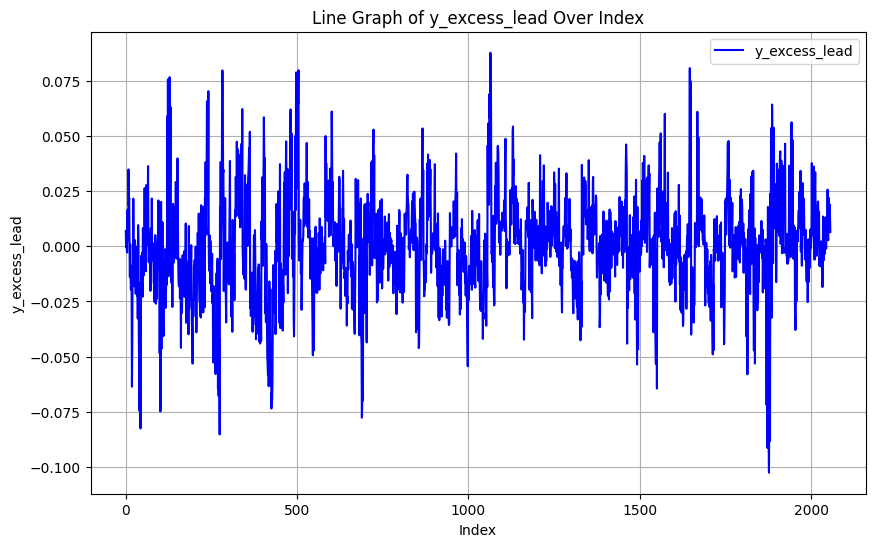

In [133]:
import matplotlib.pyplot as plt

# Plot the line graph
plt.figure(figsize=(10, 6))
plt.plot(train_df.index, train_df['y_excess_lead'], label='y_excess_lead', color='blue')

# Add labels and title
plt.xlabel('Index')
plt.ylabel('y_excess_lead')
plt.title('Line Graph of y_excess_lead Over Index')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

For benchmarking consider how the model does compared to the average. 
